# Fine-tune GLM-OCR for Vietnamese Diacritical Marks (v3)

Follows the official guide: [examples/finetune/README.md](https://github.com/zai-org/GLM-OCR/blob/main/examples/finetune/README.md)

**Dataset format:** ShareGPT with `messages`/`role`/`content` + `images` fields.

**Workflow:**
1. Chạy các bước 1→5 (setup môi trường + dataset, chỉ 1 lần)
2. Bước 6: Train 3 epoch + auto-eval từng checkpoint trên test set (50 ảnh)
3. Bước 7: Test ảnh bất kỳ (upload / dataset / path) so sánh gốc vs finetuned
4. Model tốt nhất tại `/kaggle/working/ocr_data/glm-ocr-vn-best/`

**Config (v3):**
- `freeze_vision_tower: true` + `freeze_multi_modal_projector: true` — chỉ train LLM
- LoRA rank=8, alpha=32 (official config)
- 3 epoch, 3000 samples train, ko validate, test 50 ảnh

  - Structure: `vietnamese_ocr_v2/{table,text_multi_line,text_single_line}/<source>.json` + `images/`

**Requirements:**
- Dataset đã upload lên Kaggle Datasets: `dngnguyntun2/vietnamese-ocr-v2`
- GPU: T4 (16GB) or better  (Kaggle Notebook)

In [1]:
# ═════════════════════════════════════════════════════════════════
# ⚙️  CONFIG — Single Source of Truth. Sửa ở đây, mọi cell auto-adapt.
# ═════════════════════════════════════════════════════════════════
import os, torch

# ── Paths (Kaggle) ───────────────────────────────────────────────
KAGGLE_ROOT  = '/kaggle/input/datasets/dngnguyntun2/vietnamese-ocr-v2'
KAGGLE_DATA   = KAGGLE_ROOT  # root contains 3 source folders directly
TEXT_SINGLE_DIR = os.path.join(KAGGLE_DATA, 'text_single_line')
TEXT_MULTI_DIR  = os.path.join(KAGGLE_DATA, 'text_multi_line')
TABLE_DIR       = os.path.join(KAGGLE_DATA, 'table')
SOURCE_DIRS   = {
    'text_single_line': TEXT_SINGLE_DIR,
    'text_multi_line': TEXT_MULTI_DIR,
    'table': TABLE_DIR,
}
WORKING_DIR   = '/kaggle/working'
MODEL_DIR     = "/kaggle/working/GLM-OCR"                    # base model
LF_DIR        = "/kaggle/working/LLaMA-Factory"
LF_DATA       = os.path.join(LF_DIR, 'data')
OUT_DIR       = "/kaggle/working/ocr_data"
CKPT_BASE     = os.path.join(OUT_DIR, "glm-ocr-vn-v2-ckpts")
TEST_JSON     = os.path.join(WORKING_DIR, 'vietnamese_ocr_test.json')
RESULTS_V2    = os.path.join(OUT_DIR, "experiment_v2_results.json")         # LITE
RESULTS_FULL  = os.path.join(OUT_DIR, "experiment_v2_results_full.json")    # FULL (cache)
TRAIN_META    = os.path.join(OUT_DIR, "train_metadata.json")
BEST_DEST     = "/kaggle/working/glm-ocr-vn-best"            # top-level publish
DATA_DIR      = KAGGLE_DATA                                  # legacy alias

# ── Dataset Split ────────────────────────────────────────────────
SEED          = 42
MAX_TRAIN     = 64         # tổng số mẫu train (None = lấy hết theo tỉ lệ)
N_VAL         = 0          # ko validate (như user yêu cầu)
N_TEST        = 20         # test set nhỏ
RAND_ORDER    = True
# Tỉ lệ sample từ mỗi source (trọng số, không cần chuẩn hoá).
# Đặt 0 để bỏ source đó. Ví dụ: text gấp 4 lần table.
SOURCE_RATIO = {
    'text_single_line': 2,
    'text_multi_line':  2,
    'table':            1,
}

# ── Training ─────────────────────────────────────────────────────
EPOCHS            = 1          # 3 epoch (như user yêu cầu)
PER_DEVICE_BS     = 2        # 2 GPU × BS=2 × GA=4 = eff BS 16 (giữ DDP song song 2 GPU)
GRAD_ACCUM        = 4        # GA=4 giữ eff BS=16
LEARNING_RATE     = 1.0e-5
LR_SCHEDULER      = 'constant_with_warmup'
WARMUP_RATIO      = 0.05
FP16              = True
GRAD_CHECKPOINT   = True     # ← BẬT: tránh OOM khi train GLM-OCR trên T4
PLOT_LOSS         = True
CUTOFF_LEN        = 1024     # hạ từ 2048 để giảm footprint logits (vocab 59392 → tensor lớn)
PREPROC_WORKERS   = 8
DATALOADER_WORKERS = 2
# NOTE: shuffle train batch mỗi epoch là default True của HF Trainer
# (RandomSampler) — không cần key 'dataloader_shuffle' (LF reject key này).
EVAL_STRATEGY     = 'no'      # ko validate trong train (như user yêu cầu)

# ── LoRA ─────────────────────────────────────────────────────────
LORA_RANK    = 8           # rank 8 (như user yêu cầu)
LORA_ALPHA   = 32          # alpha 32 (như user yêu cầu)
LORA_DROPOUT = 0.0
LORA_TARGET  = 'all'       # 'all' = auto-scope LM linears (OK khi vision/projector FROZEN)
FREEZE_VISION_TOWER    = True       # freeze vision tower (như user yêu cầu)
FREEZE_MULTIMODAL_PROJ = True       # freeze projector (như user yêu cầu)

# ── Hardware (auto) ──────────────────────────────────────────────
N_GPUS          = max(1, torch.cuda.device_count())

# ── Eval (cho cell EVAL, không phải LF eval_dataset) ─────────────
N_EVAL          = 20          # DEMO: eval trên 20 mẫu đầu của test set

# ── Derived (auto-computed, KHÔNG sửa) ───────────────────────────
EFFECTIVE_BS    = PER_DEVICE_BS * N_GPUS * GRAD_ACCUM
_TRAIN_AVAIL    = 60300 - N_TEST - N_VAL
TRAIN_SAMPLES   = MAX_TRAIN if MAX_TRAIN else _TRAIN_AVAIL
STEPS_PER_EPOCH = max(1, TRAIN_SAMPLES // EFFECTIVE_BS)

def _y(v): return 'true' if v else 'false'    # YAML bool helper

print(f"⚙️  Config loaded | {TRAIN_SAMPLES} samples × {EPOCHS} epochs × {N_GPUS} GPU")
print(f"   effective_bs={EFFECTIVE_BS}, steps/epoch≈{STEPS_PER_EPOCH}")
print(f"   dataset root = {KAGGLE_DATA}")
print(f"   SOURCE_RATIO={SOURCE_RATIO}")
print(f"   LoRA rank={LORA_RANK} α={LORA_ALPHA}, LR={LEARNING_RATE}, "
      f"vision={'UNFROZEN' if not FREEZE_VISION_TOWER else 'FROZEN'} | "
      f"proj={'UNFROZEN' if not FREEZE_MULTIMODAL_PROJ else 'FROZEN'}")
print(f"   N_TEST={N_TEST}, N_EVAL={N_EVAL}, N_VAL={N_VAL}")
print(f"   OUT_DIR = {OUT_DIR}")

⚙️  Config loaded | 64 samples × 1 epochs × 2 GPU
   effective_bs=16, steps/epoch≈4
   dataset root = /kaggle/input/datasets/dngnguyntun2/vietnamese-ocr-v2
   SOURCE_RATIO={'text_single_line': 2, 'text_multi_line': 2, 'table': 1}
   LoRA rank=8 α=32, LR=1e-05, vision=FROZEN | proj=FROZEN
   N_TEST=20, N_EVAL=20, N_VAL=0
   OUT_DIR = /kaggle/working/ocr_data


## 1. Check GPU

In [2]:
!nvidia-smi

Thu Jul  9 09:25:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Mount Drive & Extract Dataset

Dataset được tải qua `kagglehub` (idempotent - cached). Sử dụng `/kaggle/input` **trực tiếp** (read-only), không copy ảnh. Chỉ tạo file JSON split (KB) trong `/kaggle/working`.

In [ ]:
import kagglehub, os, json

# Paths trong CONFIG cell: KAGGLE_ROOT/KAGGLE_DATA + 3 source folders.
# kagglehub chỉ đảm bảo dataset đã được cache/mount; ta đọc trực tiếp từ /kaggle/input.
mounts = ["/kaggle/input", "/kaggle/input/datasets", "/kaggle/input/dngnguyntun2-vietnamese-ocr-v2", "/kaggle/input/vietnamese-ocr-v2"]
print('Input mount candidates:')
for p in mounts:
    print(f'  {p}:', os.path.exists(p))

kagglehub.dataset_download('dngnguyntun2/vietnamese-ocr-v2')

# Detect the actual mounted dataset root dynamically.
candidates = [
    os.path.join('/kaggle/input', 'dngnguyntun2-vietnamese-ocr-v2', 'vietnamese_ocr_v2'),
    os.path.join('/kaggle/input', 'dngnguyntun2-vietnamese-ocr-v2'),
    os.path.join('/kaggle/input', 'vietnamese-ocr-v2', 'vietnamese_ocr_v2'),
    os.path.join('/kaggle/input', 'vietnamese-ocr-v2'),
    os.path.join('/kaggle/input', 'datasets', 'dngnguyntun2', 'vietnamese-ocr-v2', 'vietnamese_ocr_v2'),
    os.path.join('/kaggle/input', 'datasets', 'dngnguyntun2', 'vietnamese-ocr-v2'),
]
resolved_root = next((p for p in candidates if os.path.exists(p)), None)
assert resolved_root, f'Could not resolve dataset root. Candidates: {candidates}'

KAGGLE_ROOT = os.path.dirname(resolved_root) if resolved_root.endswith('vietnamese_ocr_v2') else resolved_root
KAGGLE_DATA = resolved_root
TEXT_SINGLE_DIR = os.path.join(KAGGLE_DATA, 'text_single_line')
TEXT_MULTI_DIR  = os.path.join(KAGGLE_DATA, 'text_multi_line')
TABLE_DIR       = os.path.join(KAGGLE_DATA, 'table')
SOURCE_DIRS = {
    'text_single_line': TEXT_SINGLE_DIR,
    'text_multi_line': TEXT_MULTI_DIR,
    'table': TABLE_DIR,
}

print(f'Resolved KAGGLE_ROOT = {KAGGLE_ROOT}')
print(f'Resolved KAGGLE_DATA = {KAGGLE_DATA}')
assert os.path.exists(KAGGLE_DATA), f'Dataset root not found at {KAGGLE_DATA}'
assert os.path.exists(TEXT_SINGLE_DIR), f'Missing source dir: {TEXT_SINGLE_DIR}'
assert os.path.exists(TEXT_MULTI_DIR), f'Missing source dir: {TEXT_MULTI_DIR}'
assert os.path.exists(TABLE_DIR), f'Missing source dir: {TABLE_DIR}'

for name, d in SOURCE_DIRS.items():
    img_dir = os.path.join(d, 'images')
    jf = os.path.join(d, f'{name}.json')
    print(f'  {name}: {d} | images={len(os.listdir(img_dir))} | json={jf}')

# Load một mẫu từ mỗi source để xác minh format thật sự đúng.
for name, d in SOURCE_DIRS.items():
    jf = os.path.join(d, f'{name}.json')
    with open(jf, 'r', encoding='utf-8') as f:
        data = json.load(f)
    print(f'[{name}] samples={len(data)}')
    print('  sample[0].images =', data[0]['images'])
    print('  sample[0].prompt =', data[0]['messages'][0]['content'])

# Tỉ lệ từng source đã set ở CONFIG (SOURCE_RATIO).
# Cell split sẽ pick mẫu theo tỉ lệ đó, capped bởi số mẫu có sẵn của từng source.

Input mount candidates:
  /kaggle/input: True
  /kaggle/input/datasets: True
  /kaggle/input/dngnguyntun2-vietnamese-ocr-v2: False
  /kaggle/input/vietnamese-ocr-v2: False
Resolved KAGGLE_ROOT = /kaggle/input/datasets/dngnguyntun2/vietnamese-ocr-v2
Resolved KAGGLE_DATA = /kaggle/input/datasets/dngnguyntun2/vietnamese-ocr-v2
  text_single_line: /kaggle/input/datasets/dngnguyntun2/vietnamese-ocr-v2/text_single_line | images=1000 | json=/kaggle/input/datasets/dngnguyntun2/vietnamese-ocr-v2/text_single_line/text_single_line.json
  text_multi_line: /kaggle/input/datasets/dngnguyntun2/vietnamese-ocr-v2/text_multi_line | images=1000 | json=/kaggle/input/datasets/dngnguyntun2/vietnamese-ocr-v2/text_multi_line/text_multi_line.json
  table: /kaggle/input/datasets/dngnguyntun2/vietnamese-ocr-v2/table | images=1000 | json=/kaggle/input/datasets/dngnguyntun2/vietnamese-ocr-v2/table/table.json
[text_single_line] samples=1000
  sample[0].images = ['images/txt_00000.png']
  sample[0].prompt = <image>T

In [4]:
# Prepare dataset for LLaMA-Factory using ABSOLUTE image paths into /kaggle/input.
# Pick mẫu theo SOURCE_RATIO (tỉ lệ), capped bởi số mẫu có sẵn mỗi source.
import os, json, random
from collections import Counter as _C

os.makedirs(LF_DATA, exist_ok=True)

SOURCE_FILES = {
    'text_single_line': os.path.join(TEXT_SINGLE_DIR, 'text_single_line.json'),
    'text_multi_line':  os.path.join(TEXT_MULTI_DIR,  'text_multi_line.json'),
    'table':            os.path.join(TABLE_DIR,       'table.json'),
}

def _load_source(name):
    with open(SOURCE_FILES[name], 'r', encoding='utf-8') as f:
        return json.load(f)

# Load all sources
all_sources = {name: _load_source(name) for name in SOURCE_FILES}
for name, samples in all_sources.items():
    print(f'{name}: {len(samples)} samples')

# Active sources theo SOURCE_RATIO (>0)
active = [n for n in SOURCE_FILES if SOURCE_RATIO.get(n, 0) > 0]
ratios = [SOURCE_RATIO[n] for n in active]
total_r = float(sum(ratios))
print(f'Active sources (ratio>0): {active} | ratios={ratios}')

# Shuffle index mỗi source theo SEED (stratified)
ratio_rng = random.Random(SEED)
have = {n: list(range(len(all_sources[n]))) for n in active}
for n in have:
    ratio_rng.shuffle(have[n])

# Reserve test/val theo tỉ lệ (làm tròn, capped)
val_idx_src  = {n: set() for n in active}
test_idx_src = {n: list() for n in active}
rem_per_src  = {n: [] for n in active}
for i, n in enumerate(active):
    share = ratios[i] / total_r
    n_test = min(round(N_TEST * share), len(have[n]))
    n_val  = min(round(N_VAL  * share), len(have[n]) - n_test)
    test_idx_src[n] = have[n][:n_test]
    val_idx_src[n]  = set(have[n][n_test:n_test + n_val])
    rem_per_src[n]  = have[n][n_test + n_val:]
    print(f'  reserve {n}: test={n_test} val={n_val} → train pool={len(rem_per_src[n])}')

# Pick train theo tỉ lệ, capped bởi (a) pool size, (b) MAX_TRAIN.
def _pick_train(per_src, weights, want):
    """Lấy `want` mẫu tổng, chia theo weights, capped mỗi source."""
    pool = {n: list(v) for n, v in per_src.items()}
    picks = {}
    remaining = want
    guard = 0
    while remaining > 0 and guard < 1000:
        guard += 1
        w_sum = float(sum(weights[n] for n in pool if pool[n] and weights[n] > 0))
        if w_sum <= 0:
            break
        progressed = False
        for n in list(pool.keys()):
            w = weights[n]
            if w <= 0 or not pool[n]:
                continue
            share = remaining * w / w_sum
            take = min(int(share), len(pool[n]), remaining)
            if take <= 0:
                continue
            picks.setdefault(n, []).extend(pool[n][:take])
            pool[n] = pool[n][take:]
            remaining -= take
            progressed = True
        if not progressed:
            break
    return picks

train_pool = {n: list(rem_per_src[n]) for n in active}
weights = {n: SOURCE_RATIO[n] for n in active}
train_want = MAX_TRAIN if MAX_TRAIN is not None else sum(len(v) for v in train_pool.values())
train_idx_src = _pick_train(train_pool, weights, train_want)

chosen_data = []
print('\nTrain picked by ratio:')
for n in active:
    ids = train_idx_src.get(n, [])
    print(f'  {n}: {len(ids)} (ratio={SOURCE_RATIO[n]})')
    for i in ids:
        chosen_data.append({**all_sources[n][i], '_source': n})
print(f'Total chosen train samples: {len(chosen_data)}')

# Convert relative image paths → ABSOLUTE paths vào /kaggle/input
def _to_abs(item):
    item = dict(item)
    src = item.get('_source')
    source_dir = SOURCE_DIRS[src]
    item['images'] = [os.path.join(source_dir, 'images', os.path.basename(p)) for p in item['images']]
    return item

# Shuffle train (đã pick theo tỉ lệ, không cắt thêm)
if RAND_ORDER:
    rng = random.Random(SEED + 1)
    rng.shuffle(chosen_data)

train_data = [_to_abs(it) for it in chosen_data]
val_data   = [_to_abs({**all_sources[n][i], '_source': n}) for n in active for i in val_idx_src[n]]
test_data  = [_to_abs({**all_sources[n][i], '_source': n}) for n in active for i in test_idx_src[n]]

print(f'\nSplit [{SEED}]: {len(train_data)} train / {len(val_data)} val / {len(test_data)} test')
_src_count = _C(it.get('_source') for it in train_data)
print(f'  train by source: {dict(_src_count)}')
print(f'  → image paths now ABSOLUTE into source folders under {KAGGLE_DATA}')

# Write split JSONs
with open(os.path.join(LF_DATA, 'vietnamese_ocr.json'), 'w', encoding='utf-8') as f:
    json.dump(train_data, f, ensure_ascii=False)
with open(os.path.join(LF_DATA, 'vietnamese_ocr_val.json'), 'w', encoding='utf-8') as f:
    json.dump(val_data, f, ensure_ascii=False)
with open(os.path.join(LF_DATA, 'vietnamese_ocr_test.json'), 'w', encoding='utf-8') as f:
    json.dump(test_data, f, ensure_ascii=False)
os.makedirs(WORKING_DIR, exist_ok=True)
with open(os.path.join(WORKING_DIR, 'vietnamese_ocr_test.json'), 'w', encoding='utf-8') as f:
    json.dump(test_data, f, ensure_ascii=False)
print('✓ Wrote 3 split JSONs to LF/data and 1 test JSON to working')

print(f'  paths to LF_DIR/data: {LF_DATA}')
missing = sum(
    1 for item in train_data + val_data + test_data
    for img in item['images']
    if not os.path.exists(img)
)
print(f'Missing images: {missing}  (must be 0)')
assert missing == 0, 'Some images are missing — check source dirs under KAGGLE_DATA'

print(f'\nSample train[0] images: {train_data[0]["images"]}')

# Register datasets in dataset_info.json
ds_info_path = os.path.join(LF_DATA, 'dataset_info.json')
if not os.path.exists(ds_info_path):
    info = {}
else:
    with open(ds_info_path, 'r', encoding='utf-8') as f:
        info = json.load(f)

for name, fname in [('vietnamese_ocr', 'vietnamese_ocr.json'),
                    ('vietnamese_ocr_val', 'vietnamese_ocr_val.json'),
                    ('vietnamese_ocr_test', 'vietnamese_ocr_test.json')]:
    info[name] = {
        'file_name': fname,
        'formatting': 'sharegpt',
        'columns': {'messages': 'messages', 'images': 'images'},
        'tags': {'role_tag': 'role', 'content_tag': 'content', 'user_tag': 'user', 'assistant_tag': 'assistant'}
    }

with open(ds_info_path, 'w', encoding='utf-8') as f:
    json.dump(info, f, indent=2, ensure_ascii=False)

print(f'OK: registered train ({len(train_data)}) / val ({len(val_data)}) / test ({len(test_data)})')

text_single_line: 1000 samples
text_multi_line: 1000 samples
table: 1000 samples
Active sources (ratio>0): ['text_single_line', 'text_multi_line', 'table'] | ratios=[2, 2, 1]
  reserve text_single_line: test=8 val=0 → train pool=992
  reserve text_multi_line: test=8 val=0 → train pool=992
  reserve table: test=4 val=0 → train pool=996

Train picked by ratio:
  text_single_line: 36 (ratio=2)
  text_multi_line: 21 (ratio=2)
  table: 5 (ratio=1)
Total chosen train samples: 62

Split [42]: 62 train / 0 val / 20 test
  train by source: {'text_multi_line': 21, 'text_single_line': 36, 'table': 5}
  → image paths now ABSOLUTE into source folders under /kaggle/input/datasets/dngnguyntun2/vietnamese-ocr-v2
✓ Wrote 3 split JSONs to LF/data and 1 test JSON to working
  paths to LF_DIR/data: /kaggle/working/LLaMA-Factory/data
Missing images: 0  (must be 0)

Sample train[0] images: ['/kaggle/input/datasets/dngnguyntun2/vietnamese-ocr-v2/text_multi_line/images/ml_00083.png']
OK: registered train (62)

## 3. Install LLaMA-Factory

In [5]:
# Install LLaMA-Factory + pin transformers
import os
os.chdir('/kaggle/working')
!git clone --depth 1 https://github.com/hiyouga/LLaMA-Factory.git
%cd /kaggle/working/LLaMA-Factory
!pip install -e ".[torch,metrics]" 2>&1 | tail -5

# Pin transformers 5.6.0 — compatible with both LLaMA-Factory (>=4.55, <=5.6.0) and GLM-OCR (>=5.3.0)
!pip install transformers==5.6.0 2>&1 | tail -3

!llamafactory-cli version

fatal: destination path 'LLaMA-Factory' already exists and is not an empty directory.
/kaggle/working/LLaMA-Factory
  Attempting uninstall: llamafactory
    Found existing installation: llamafactory 0.9.6.dev0
    Uninstalling llamafactory-0.9.6.dev0:
      Successfully uninstalled llamafactory-0.9.6.dev0
----------------------------------------------------------
| Welcome to LLaMA Factory, version 0.9.6.dev0           |
|                                                        |
| Project page: https://github.com/hiyouga/LLaMA-Factory |
----------------------------------------------------------


## 4. Download GLM-OCR Model

In [6]:
from huggingface_hub import snapshot_download

# MODEL_DIR đã set trong CONFIG cell (cell 1).
model_dir = snapshot_download(
    "zai-org/GLM-OCR",
    local_dir=MODEL_DIR,
    local_dir_use_symlinks=False,
)
print(f"Model downloaded to: {model_dir}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Model downloaded to: /kaggle/working/GLM-OCR


---

## 6. ⚡ Train (3 epoch, vision+projector FROZEN, LoRA rank 8)

Pipeline chính: so sánh **base GLM-OCR** với **checkpoints sau khi fine-tune** tới 3 epoch. **Key config (v3):**
- `lora_target: all` — auto-scope LM linears (OK khi vision+projector FROZEN, không crash LayerNorm)
- `freeze_vision_tower: true` + `freeze_multi_modal_projector: true` — chỉ train LLM
- `lora_rank: 8, lora_alpha: 32` — official config
- 3000 samples train, ko validate, test 50 ảnh

**Flow:** train 3 epoch trong 1 lần → copy checkpoint mỗi epoch → eval từng checkpoint trên test set (50 ảnh).

> Kết quả lưu vào `experiment_v2_results.json`; model tốt nhất tại `/kaggle/working/ocr_data/glm-ocr-vn-best/`.


In [8]:
# ═════════════════════════════════════════════════════════════════
# 🚂 TRAIN ONLY — train EPOCHS epoch trong 1 lần, save each epoch ckpt
# ═════════════════════════════════════════════════════════════════
# Config v3 (như user yêu cầu):
#   - freeze_vision_tower: true  → chỉ train LLM, vision intact
#   - freeze_multi_modal_projector: true → projector intact
#   - lora_rank: 8, alpha: 32    → official config
#   - lora_target: all           → auto-scope LM linears (OK khi frozen)
#
# DESIGN:
#   - save_strategy: epoch + save_only_model: false → đầy đủ optimizer state
#   - KHÔNG eval trong cell này → eval (base + từng ckpt) ở cell EVAL ngay sau
#   - Output: CKPT_BASE/checkpoint-<step> cho ep1..epEPOCHS
# ═════════════════════════════════════════════════════════════════
import os, json, time, shutil, subprocess, gc, torch

# Paths + tunables set ở CONFIG cell (cell 1).

os.makedirs(CKPT_BASE, exist_ok=True)
print(f"⚙️  GPUs={N_GPUS}  effective_bs={EFFECTIVE_BS}  steps/epoch≈{STEPS_PER_EPOCH}")
print(f"📦 CKPT_BASE = {CKPT_BASE}")

# ═══ Hàm train EPOCHS epoch trong 1 lần, save_strategy=epoch ═══
def train_all_epochs(ckpt_dir):
    """Train EPOCHS epoch. Checkpoint-<step> được save cuối mỗi epoch."""
    yaml = f"""
model_name_or_path: {MODEL_DIR}
trust_remote_code: true
stage: sft
do_train: true
finetuning_type: lora
lora_rank: {LORA_RANK}
lora_alpha: {LORA_ALPHA}
lora_dropout: {LORA_DROPOUT}
lora_target: {LORA_TARGET}                                # 'all' auto-scope LM linears (OK khi frozen)
freeze_vision_tower: {_y(FREEZE_VISION_TOWER)}            # FROZEN: chỉ train LLM
freeze_multi_modal_projector: {_y(FREEZE_MULTIMODAL_PROJ)}
dataset: vietnamese_ocr
template: glm_ocr
cutoff_len: {CUTOFF_LEN}
preprocessing_num_workers: {PREPROC_WORKERS}
dataloader_num_workers: {DATALOADER_WORKERS}
eval_strategy: {EVAL_STRATEGY!r}
per_device_eval_batch_size: {PER_DEVICE_BS}
output_dir: "{ckpt_dir}"
logging_steps: 10
save_strategy: epoch              # ← checkpoint cuối mỗi epoch
save_total_limit: {EPOCHS}        # giữ đủ {EPOCHS} epoch checkpoint
plot_loss: {_y(PLOT_LOSS)}        # ← LLaMA-Factory draws training_loss.png
overwrite_output_dir: false
save_only_model: false            # ← full optimizer state cho resume
report_to: none
per_device_train_batch_size: {PER_DEVICE_BS}
gradient_accumulation_steps: {GRAD_ACCUM}
gradient_checkpointing: {_y(GRAD_CHECKPOINT)}  # HF Trainer flag (có thể bị LF override)
disable_gradient_checkpointing: {_y(not GRAD_CHECKPOINT)}  # ← LF-internal flag (chuẩn hơn)
learning_rate: {LEARNING_RATE}
num_train_epochs: {EPOCHS}        # train đủ {EPOCHS} epoch trong 1 lần
lr_scheduler_type: {LR_SCHEDULER!r}
warmup_ratio: {WARMUP_RATIO}
fp16: {_y(FP16)}
"""
    yaml_path = "/kaggle/working/_train_v2.yaml"
    with open(yaml_path, "w") as f: f.write(yaml)
    print(f"\n  [TRAIN] Khởi động train {EPOCHS} epoch (save_strategy=epoch)")
    print(f"  [TRAIN] YAML: {yaml_path}")
    env = os.environ.copy(); env["DISABLE_VERSION_CHECK"] = "1"
    ret = subprocess.run(["llamafactory-cli", "train", yaml_path], env=env,
                         capture_output=False)
    if ret.returncode != 0:
        raise RuntimeError(f"llamafactory-cli train fail code={ret.returncode}")
    ckpts = sorted([d for d in os.listdir(ckpt_dir) if d.startswith("checkpoint-")],
                   key=lambda x: int(x.split("-")[1]))
    if len(ckpts) < EPOCHS:
        print(f"  ⚠️ chỉ có {len(ckpts)} checkpoint (mong đợi {EPOCHS})")
    return [os.path.join(ckpt_dir, c) for c in ckpts]

# ═══ Xoá checkpoint cũ (đảm bảo train from scratch) ═══
if os.path.exists(CKPT_BASE):
    shutil.rmtree(CKPT_BASE)
os.makedirs(CKPT_BASE, exist_ok=True)

# ═══ TRAIN ═══
print(f"\n{'='*70}\n  🚂 TRAINING: {EPOCHS} epoch (single run)\n{'='*70}")
gc.collect(); torch.cuda.empty_cache()
t_train = time.time()
ckpt_list = train_all_epochs(CKPT_BASE)
train_total = time.time() - t_train
print(f"\n  ✓ Train xong trong {train_total:.0f}s — {len(ckpt_list)} checkpoint sinh ra:")
for c in ckpt_list: print(f"    - {c}")

# ── Persist train metadata (cho restart session + debug) ────────
# Bao gồm log_history (loss/lr/grad_norm mỗi step) đọc từ trainer_state.json
# của checkpoint cuối cùng. Dùng để vẽ loss curve + lr schedule + grad norm.
os.makedirs(OUT_DIR, exist_ok=True)

log_history = []
if ckpt_list:
    last_state = os.path.join(ckpt_list[-1], "trainer_state.json")
    if os.path.exists(last_state):
        with open(last_state, encoding="utf-8") as f:
            log_history = json.load(f).get("log_history", [])
        print(f"  ✓ Loaded {len(log_history)} log entries từ trainer_state.json")
    else:
        print(f"  ⚠️ {last_state} không tồn tại (save_only_model=true?)")

with open(TRAIN_META, "w", encoding="utf-8") as f:
    json.dump({
        "EPOCHS":          EPOCHS,
        "PER_DEVICE_BS":   PER_DEVICE_BS,
        "GRAD_ACCUM":      GRAD_ACCUM,
        "MAX_TRAIN":       MAX_TRAIN,
        "N_GPUS":          N_GPUS,
        "EFFECTIVE_BS":    EFFECTIVE_BS,
        "STEPS_PER_EPOCH": STEPS_PER_EPOCH,
        "train_total_s":   round(train_total, 1),
        "ckpt_list":       ckpt_list,
        "MODEL_DIR":       MODEL_DIR,
        "CKPT_BASE":       CKPT_BASE,
        "log_history":     log_history,
    }, f, indent=2, ensure_ascii=False)
print(f"  ✅ Train metadata → {TRAIN_META}")
if log_history:
    print(f"     ({len(log_history)} entries: loss/lr/grad_norm/epoch — cho dashboard)")

print(f"\n  💡 Cell tiếp theo sẽ: scan folder này → merge+eval từng ckpt → pick best.")

⚙️  GPUs=2  effective_bs=16  steps/epoch≈4
📦 CKPT_BASE = /kaggle/working/ocr_data/glm-ocr-vn-v2-ckpts

  🚂 TRAINING: 1 epoch (single run)

  [TRAIN] Khởi động train 1 epoch (save_strategy=epoch)
  [TRAIN] YAML: /kaggle/working/_train_v2.yaml
[INFO|2026-07-09 09:29:20] llamafactory.launcher:144 >> Initializing 2 distributed tasks at: 127.0.0.1:52381


W0709 09:29:22.615000 738 torch/distributed/run.py:852] 
W0709 09:29:22.615000 738 torch/distributed/run.py:852] *****************************************
W0709 09:29:22.615000 738 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0709 09:29:22.615000 738 torch/distributed/run.py:852] *****************************************


[WARNING|2026-07-09 09:29:31] llamafactory.extras.misc:155 >> Version checking has been disabled, may lead to unexpected behaviors.


/usr/local/lib/python3.12/dist-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/usr/local/lib/python3.12/dist-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[W709 09:29:38.663187218 ProcessGroupNCCL.cpp:929] Warning: TORCH_NCCL_AVOID_RECORD_STREAMS is the default now, this environment variable is thus deprecated. (function operator())
[transformers] warmup_ratio is deprecated and will be removed in v5.2

[INFO|2026-07-09 09:29:38] llamafactory.hparams.parser:144 >> Set `ddp_find_unused_parameters` to False in DDP training since LoRA is enabled.
[INFO|2026-07-09 09:29:38] llamafactory.hparams.parser:523 >> Process rank: 0, world size: 2, device: cuda:0, distributed training: True, compute dtype: torch.float16
[INFO|2026-07-09 09:29:38] llamafactory.hparams.parser:523 >> Process rank: 1, world size: 2, device: cuda:1, distributed training: True, compute dtype: torch.float16


...

[INFO|2026-07-09 09:29:40] llamafactory.data.template:144 >> Add <|user|>,<|observation|> to stop words.
[INFO|2026-07-09 09:29:40] llamafactory.data.loader:144 >> Loading dataset vietnamese_ocr.json...


Setting num_proc from 8 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Generating train split: 62 examples [00:00, 6784.42 examples/s]
Converting format of dataset (num_proc=8): 100%|██████████| 62/62 [00:00<00:00, 165.82 examples/s]
/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)
[rank0]:[W709 09:29:40.913674394 ProcessGroupNCCL.cpp:5138] Guessing device ID based on global rank. This can cause a hang if rank to GPU mapping is heterogeneous. You can specify device_id in init_process_group()
Running tokenizer on dataset (num_proc=8): 100%|██████████| 62/62 [00:02<00:00, 27.94 examples/s]
[INFO|configuration_utils.py:769] 2026-07-09 09:29:43,364 >> loading configuration file /kaggle/working/GLM-OCR/config.json
[INFO|configuration_utils.py:847] 2026-07-0

training example:
input_ids:
[59248, 59250, 59253, 10, 59256, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59280, 59257, 3649, 7404, 49600, 58, 59254, 10, 34, 21289, 112, 35538, 12752, 50841, 4846, 40974, 40689, 3004, 33898, 40689, 13674, 17207, 909, 16980, 1221, 39407, 267, 16514, 46, 59246]


[INFO|modeling_utils.py:748] 2026-07-09 09:29:44,260 >> loading weights file /kaggle/working/GLM-OCR/model.safetensors
[INFO|modeling_utils.py:834] 2026-07-09 09:29:44,264 >> Since the `dtype` attribute can't be found in model's config object, will use dtype=torch.bfloat16 as derived from model's weights
[INFO|configuration_utils.py:1027] 2026-07-09 09:29:44,266 >> Generate config GenerationConfig {
  "output_attentions": false,
  "output_hidden_states": false,
  "use_cache": false
}

Loading weights: 100%|██████████| 510/510 [00:00<00:00, 677.31it/s]
[INFO|configuration_utils.py:978] 2026-07-09 09:29:45,288 >> loading configuration file /kaggle/working/GLM-OCR/generation_config.json
[INFO|configuration_utils.py:1027] 2026-07-09 09:29:45,288 >> Generate config GenerationConfig {
  "do_sample": false,
  "eos_token_id": [
    59246,
    59253
  ],
  "pad_token_id": 59246
}

[INFO|dynamic_module_utils.py:406] 2026-07-09 09:29:45,289 >> Could not locate the custom_generate/generate.py insi


  ✓ Train xong trong 46s — 1 checkpoint sinh ra:
    - /kaggle/working/ocr_data/glm-ocr-vn-v2-ckpts/checkpoint-4
  ✓ Loaded 0 log entries từ trainer_state.json
  ✅ Train metadata → /kaggle/working/ocr_data/train_metadata.json

  💡 Cell tiếp theo sẽ: scan folder này → merge+eval từng ckpt → pick best.


📦 Tìm thấy 1 checkpoint:
    - /kaggle/working/ocr_data/glm-ocr-vn-v2-ckpts/checkpoint-4

💾 Cache HIT: /kaggle/working/ocr_data/experiment_v2_results_full.json — skip inference.
  ✓ Cache loaded: 2 epochs.

  🏆 BEST EPOCH = 1: CER=0.0594 WER=0.4332

  ✓ Merged model đã tồn tại: /kaggle/working/ocr_data/glm-ocr-vn-v2-ep1
  ✅ FULL results (cache) → /kaggle/working/ocr_data/experiment_v2_results_full.json
  ✅ LITE results → /kaggle/working/ocr_data/experiment_v2_results.json

  👑 FINAL RESULTS
   Ep |    CER↓    WER↓  EM%↑ |   Sub  Del  Ins |  Tone  Lett  Both |     ê     ô     â     ơ
  ----+-----------------------+-----------------+-------------------+------------------------
    0 |  0.0598  0.4387   5.0 |   206   63   25 |    74    51    28 |  57.7  63.3  50.0  65.5
    1 |  0.0594  0.4332   5.0 |   204   64   24 |    74    51    27 |  53.8  63.3  50.0  69.0

  📊 COMPREHENSIVE RESULTS — BEST ep1
  Macro F1  →  letter: 55.0%    tone: 29.5%

  ── TOP-15 cặp ký tự nhầm nhiều nhất ──
    

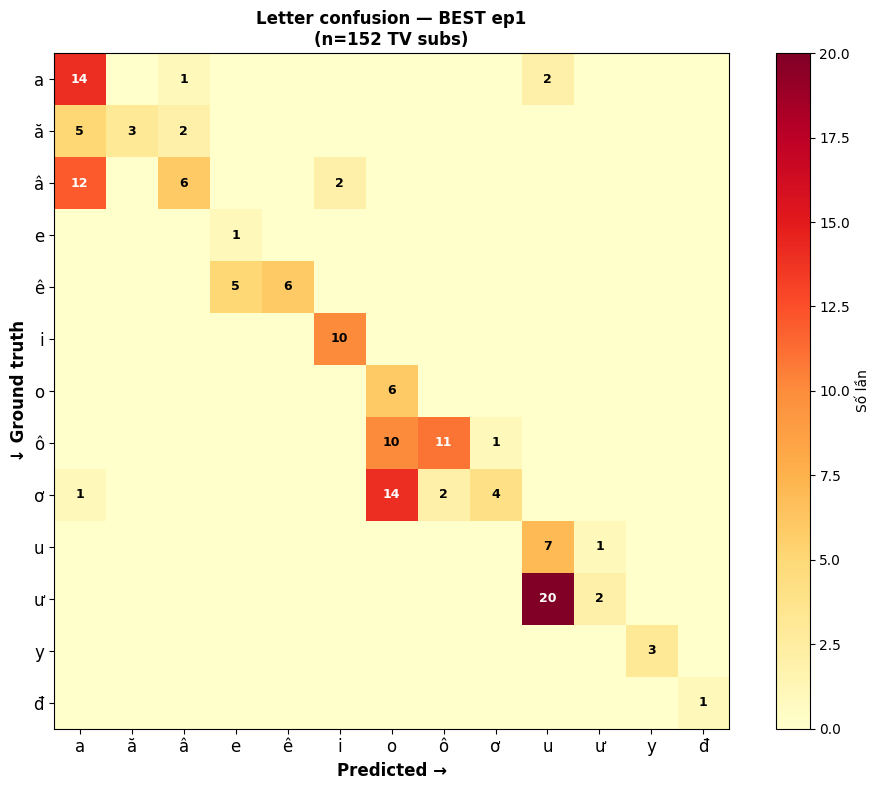


[Vẽ 2/4: heatmap DẤU]


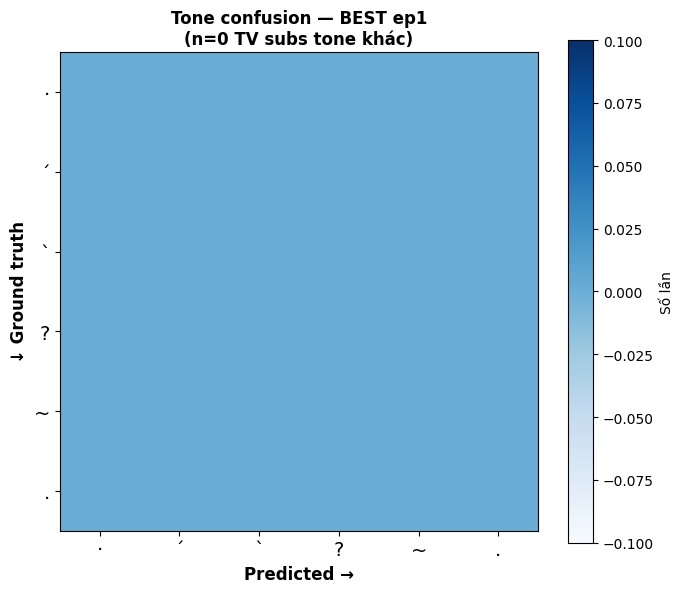


[Vẽ 3/4: bar top-15]


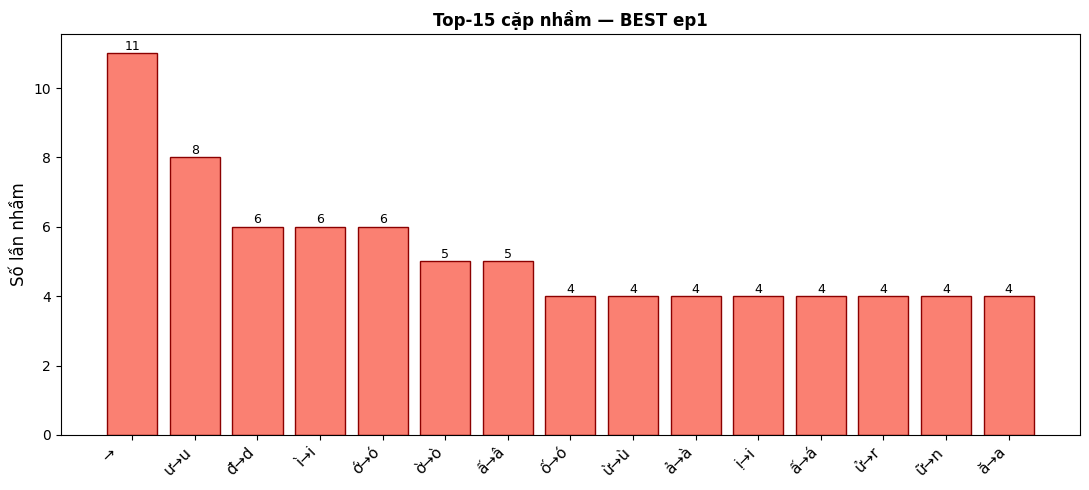


[Vẽ 4/4: histogram + scatter CER]


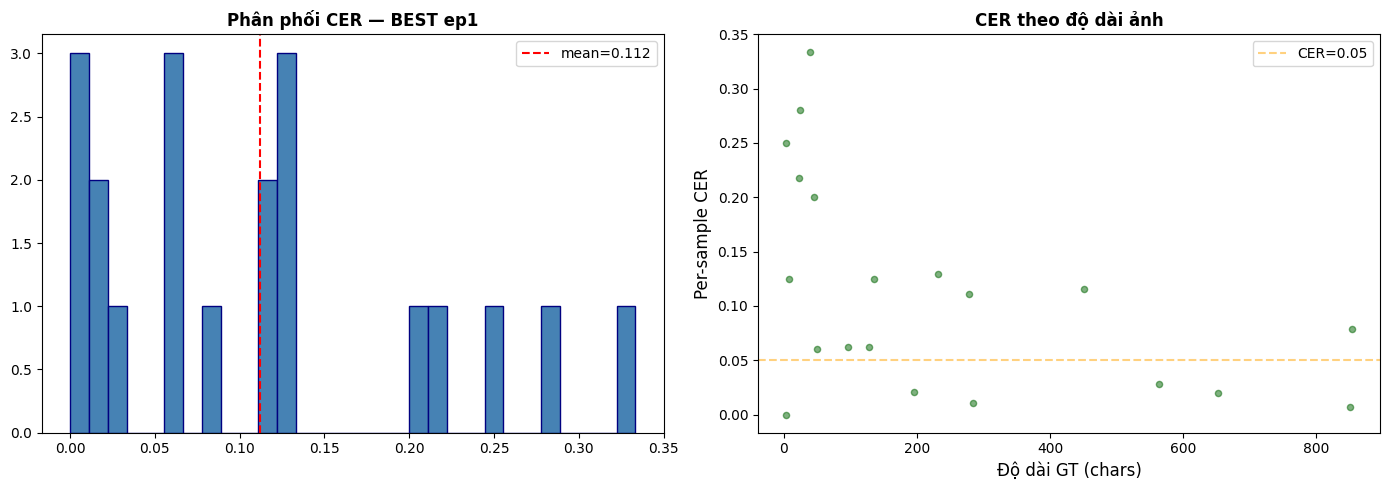


✅ All artefacts at /kaggle/working/ocr_data/: heatmap_letter, heatmap_tone, top15_pairs, cer_dist, errors_ep1.csv


In [9]:
# ═════════════════════════════════════════════════════════════════
# 📊 EVAL + COMPREHENSIVE ANALYSIS  (PEFT adapter eval + merge best only)
# ═════════════════════════════════════════════════════════════════
import os, json, time, shutil, subprocess, gc, csv
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import torch, editdistance
from transformers import AutoProcessor, AutoModelForImageTextToText
from peft import PeftModel

FORCE_REEVAL = False

assert os.path.exists(CKPT_BASE), f"CKPT_BASE không tồn tại: {CKPT_BASE}\n→ Chạy cell TRAIN trước."

ckpt_dirs = sorted([d for d in os.listdir(CKPT_BASE) if d.startswith("checkpoint-")],
                   key=lambda x: int(x.split("-")[1]))
ckpt_list = [os.path.join(CKPT_BASE, c) for c in ckpt_dirs]
print(f"📦 Tìm thấy {len(ckpt_list)} checkpoint:")
for c in ckpt_list: print(f"    - {c}")
assert ckpt_list, "Không có checkpoint nào — chạy cell TRAIN trước."

def _counter_to_dict(obj):
    if isinstance(obj, Counter):
        return { ("|".join(k) if isinstance(k, tuple) else str(k)): v for k, v in obj.items() }
    if isinstance(obj, dict):
        return { k: _counter_to_dict(v) for k, v in obj.items() }
    if isinstance(obj, list):
        return [ _counter_to_dict(x) for x in obj ]
    return obj

def _dict_to_counter(obj):
    if isinstance(obj, dict):
        out = {}
        for k, v in obj.items():
            v2 = _dict_to_counter(v) if isinstance(v, (dict, list)) else v
            if "|" in str(k):
                a, b = str(k).split("|", 1)
                out[(a, b)] = v2
            else:
                out[k] = v2
        try:
            if all(isinstance(v, (int, float)) for v in out.values()):
                return Counter(out)
        except Exception:
            pass
        return out
    if isinstance(obj, list):
        return [ _dict_to_counter(x) for x in obj ]
    return obj

# ── Cache check ──────────────────────────────────────────────────
cache_valid = False
if (not FORCE_REEVAL) and os.path.exists(RESULTS_FULL):
    try:
        with open(RESULTS_FULL) as f:
            cached = json.load(f)
        cached_ckpts = [r.get("ckpt_path", "") for r in cached.get("results", []) if r.get("epoch", 0) > 0]
        if cached_ckpts == ckpt_list and len(cached.get("results", [])) == len(ckpt_list) + 1:
            print(f"\n💾 Cache HIT: {RESULTS_FULL} — skip inference.")
            cache_valid = True
        else:
            print(f"\n⚠️ Cache STALE → re-evaluating...")
    except Exception as e:
        print(f"\n⚠️ Cache corrupt ({e}) → re-evaluating...")

# ── Vietnamese diacritic decomposition ───────────────────────────
TONES = [0,1,2,3,4,5]
TONE_NAMES  = {0:"·(none)",1:"´(sắc)",2:"`(huyền)",3:"?(hỏi)",4:"~(ngã)",5:".(nặng)"}
TONE_SYMBOL = {0:"·",1:"´",2:"`",3:"?",4:"~",5:"."}
BASE_LETTERS = ["a","ă","â","e","ê","i","o","ô","ơ","u","ư","y","đ"]
_VI_TABLE = {
    ("a",0):"a",("a",1):"á",("a",2):"à",("a",3):"ả",("a",4):"ã",("a",5):"ạ",
    ("ă",0):"ă",("ă",1):"ắ",("ă",2):"ằ",("ă",3):"ẳ",("ă",4):"ẵ",("ă",5):"ặ",
    ("â",0):"â",("â",1):"ấ",("â",2):"ầ",("â",3):"ẩ",("â",4):"ẫ",("â",5):"ậ",
    ("e",0):"e",("e",1):"é",("e",2):"è",("e",3):"ẻ",("e",4):"ẽ",("e",5):"ẹ",
    ("ê",0):"ê",("ê",1):"ế",("ê",2):"ề",("ê",3):"ể",("ê",4):"ễ",("ê",5):"ệ",
    ("i",0):"i",("i",1):"í",("i",2):"ì",("i",3):"ỉ",("i",4):"ĩ",("i",5):"ị",
    ("o",0):"o",("o",1):"ó",("o",2):"ò",("o",3):"ỏ",("o",4):"õ",("o",5):"ọ",
    ("ô",0):"ô",("ô",1):"ố",("ô",2):"ồ",("ô",3):"ổ",("ô",4):"ỗ",("ô",5):"ộ",
    ("ơ",0):"ơ",("ơ",1):"ớ",("ơ",2):"ờ",("ơ",3):"ở",("ơ",4):"ỡ",("ơ",5):"ợ",
    ("u",0):"u",("u",1):"ú",("u",2):"ù",("u",3):"ủ",("u",4):"ũ",("u",5):"ụ",
    ("ư",0):"ư",("ư",1):"ứ",("ư",2):"ừ",("ư",3):"ử",("ư",4):"ữ",("ư",5):"ự",
    ("y",0):"y",("y",1):"ý",("y",2):"ỳ",("y",3):"ỷ",("y",4):"ỹ",("y",5):"ỵ",
    ("đ",0):"đ",("đ",1):"đ",("đ",2):"đ",("đ",3):"đ",("đ",4):"đ",("đ",5):"đ",
}
CHAR2BT = {c:(b,t) for (b,t),c in _VI_TABLE.items()}; CHAR2BT["Đ"] = ("đ",0)
def decompose(c): return CHAR2BT.get(c,(None,None))

def align_chars(gt, pred):
    m, n = len(gt), len(pred)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1): dp[i][0] = i
    for j in range(n+1): dp[0][j] = j
    for i in range(1,m+1):
        for j in range(1,n+1):
            dp[i][j] = dp[i-1][j-1] if gt[i-1]==pred[j-1] else 1+min(dp[i-1][j],dp[i][j-1],dp[i-1][j-1])
    out,i,j=[],m,n
    while i>0 or j>0:
        if i>0 and j>0 and gt[i-1]==pred[j-1]:
            out.append(("match",gt[i-1],pred[j-1])); i-=1; j-=1
        elif i>0 and j>0 and dp[i][j]==dp[i-1][j-1]+1:
            out.append(("sub",gt[i-1],pred[j-1])); i-=1; j-=1
        elif i>0 and dp[i][j]==dp[i-1][j]+1:
            out.append(("del",gt[i-1],"")); i-=1
        else:
            out.append(("ins","",pred[j-1])); j-=1
    out.reverse(); return out

def _prf(tp, gt_n, pred_n):
    p  = tp/pred_n if pred_n else 0.0
    r  = tp/gt_n   if gt_n   else 0.0
    f1 = 2*p*r/(p+r) if (p+r) else 0.0
    return round(p*100,1), round(r*100,1), round(f1*100,1)

# ── Hàm eval 1 model_dir (+ optional LoRA adapter) → FULL metric dict ──
def evaluate_model(model_dir, adapter_path=None, progress_tag=""):
    with open(TEST_JSON, "r", encoding="utf-8") as f:
        td = json.load(f)
    tag = os.path.basename(model_dir) + (f" + {os.path.basename(adapter_path)}" if adapter_path else "")
    n_eval = min(N_EVAL, len(td))
    print(f"\n  [EVAL{progress_tag}] {n_eval} samples (N_EVAL={N_EVAL}) — {tag}")
    gc.collect(); torch.cuda.empty_cache()
    proc = AutoProcessor.from_pretrained(model_dir, trust_remote_code=True)
    mdl = AutoModelForImageTextToText.from_pretrained(
        model_dir, trust_remote_code=True, torch_dtype="auto", device_map="cuda:0"
    )
    if adapter_path:
        print(f"    ↳ Attach LoRA adapter: {adapter_path}")
        mdl = PeftModel.from_pretrained(mdl, adapter_path)
    mdl.eval()
    GEN_KW = dict(max_new_tokens=512, do_sample=False)
    pairs = []
    t0 = time.time()
    for i, item in enumerate(td[:n_eval]):
        gt = item["messages"][1]["content"]
        img_path = item["images"][0]
        # Đọc đúng prompt từ mỗi mẫu ('<image>Text Recognition:' hoặc '<image>Table Recognition:')
        raw_prompt = item["messages"][0]["content"]
        task_text = raw_prompt.replace("<image>", "").strip() or "Text Recognition:"
        msgs = [{"role":"user","content":[{"type":"image","url":img_path},
                                         {"type":"text","text":task_text}]}]
        inputs = proc.apply_chat_template(msgs, tokenize=True, add_generation_prompt=True,
                                          return_dict=True, return_tensors="pt")
        inputs.pop("token_type_ids", None)
        inputs = inputs.to(mdl.device)
        with torch.inference_mode():
            gen = mdl.generate(**inputs, **GEN_KW)
        pred = proc.decode(gen[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
        pairs.append((gt, pred))
        if (i+1) % 25 == 0:
            print(f"    {i+1}/{n_eval} ({(i+1)/(time.time()-t0):.1f}/s)", flush=True)
    fps = len(pairs)/max(1e-6, time.time()-t0)
    del mdl; gc.collect(); torch.cuda.empty_cache()

    S = {"cer_t":0,"cer_c":0,"wer_t":0,"wer_w":0,"em":0}
    ops = Counter(); sub_pairs = Counter(); err = Counter()
    conf_letter = {b:Counter() for b in BASE_LETTERS}
    conf_tone   = {t:Counter() for t in TONES}
    per_letter  = {b:{"correct":0,"total":0} for b in BASE_LETTERS}
    len_buckets = []; errors_csv = []

    for gt, pred in pairs:
        n_chars = max(len(gt), 1)
        sample_cer = editdistance.eval(pred, gt) / n_chars
        len_buckets.append((len(gt), sample_cer))
        if pred == gt:
            S["em"] += 1
        else:
            errors_csv.append({"gt": gt, "pred": pred, "sample_cer": round(sample_cer, 4)})
        S["cer_t"] += editdistance.eval(pred, gt); S["cer_c"] += n_chars
        gw, pw = gt.split(), pred.split()
        S["wer_t"] += editdistance.eval(pw,gw); S["wer_w"] += max(len(gw),1)

        for op, cg, cp in align_chars(gt, pred):
            ops[op] += 1
            if op == "sub":
                sub_pairs[(cg,cp)] += 1
                bg, tg = decompose(cg); bp, tp = decompose(cp)
                if bg and bp:
                    conf_letter[bg][bp] += 1
                    if tg is not None and tp is not None:
                        conf_tone[tg][tp] += 1
                    if bg == bp and tg != tp: err["tone_only"]   += 1
                    elif bg != bp and tg == tp: err["letter_only"] += 1
                    elif bg != bp and tg != tp: err["both"]       += 1
                else:
                    err["other"] += 1

        for op, cg, cp in align_chars(gt, pred):
            if cg == "": continue
            bg, tg = decompose(cg)
            if bg is None: continue
            per_letter[bg]["total"] += 1
            if op == "match" or (op == "sub" and decompose(cp)[1] == tg):
                per_letter[bg]["correct"] += 1

    tone_acc = {b: round(per_letter[b]["correct"]/per_letter[b]["total"]*100,1)
                      if per_letter[b]["total"] else None for b in BASE_LETTERS}
    letter_prf = {}
    for b in BASE_LETTERS:
        tp_n = conf_letter[b][b]
        gt_n = sum(conf_letter[b].values())
        pred_n = sum(conf_letter[b2][b] for b2 in BASE_LETTERS)
        letter_prf[b] = _prf(tp_n, gt_n, pred_n)
    macro_letter_f1 = round(sum(v[2] for v in letter_prf.values())/len(BASE_LETTERS), 1)
    tone_prf = {}
    for t in TONES:
        tp_n = conf_tone[t][t]
        gt_n = sum(conf_tone[t].values())
        pred_n = sum(conf_tone[t2][t] for t2 in TONES)
        tone_prf[t] = _prf(tp_n, gt_n, pred_n)
    macro_tone_f1 = round(sum(v[2] for v in tone_prf.values())/len(TONES), 1)

    return {
        "n": n_eval, "fps": round(fps,1),
        "CER": round(S["cer_t"]/max(S["cer_c"],1),4),
        "WER": round(S["wer_t"]/max(S["wer_w"],1),4),
        "EM%": round(S["em"]/n_eval*100,1) if n_eval else 0.0,
        "ops_match": ops["match"], "ops_sub": ops["sub"],
        "ops_del": ops["del"], "ops_ins": ops["ins"],
        "tone_only": err["tone_only"], "letter_only": err["letter_only"],
        "both": err["both"], "other": err["other"],
        "tone_acc": tone_acc,
        "_conf_letter": conf_letter, "_conf_tone": conf_tone,
        "_sub_pairs": sub_pairs, "_letter_prf": letter_prf, "_tone_prf": tone_prf,
        "_macro_letter_f1": macro_letter_f1, "_macro_tone_f1": macro_tone_f1,
        "_len_buckets": len_buckets, "_errors_csv": errors_csv,
    }

def merge_lora(ckpt, export_dir):
    if os.path.exists(export_dir): shutil.rmtree(export_dir)
    env = os.environ.copy()
    subprocess.run([
        "llamafactory-cli", "export",
        "--model_name_or_path", MODEL_DIR,
        "--adapter_name_or_path", ckpt,
        "--template", "glm_ocr",
        "--export_dir", export_dir,
        "--trust_remote_code", "true",
    ], env=env, capture_output=False, check=True)
    return export_dir

# ═══ START EVAL Pipeline ═══
results = []

if cache_valid:
    results = cached["results"]
    for r in results:
        for k in ["_conf_letter", "_conf_tone", "_sub_pairs", "_letter_prf", "_tone_prf"]:
            if k in r:
                r[k] = _dict_to_counter(r[k])
        if "_conf_tone" in r:
            r["_conf_tone"] = {int(k) if isinstance(k,str) and k.isdigit() else k: v for k,v in r["_conf_tone"].items()}
        if "_tone_prf" in r:
            r["_tone_prf"] = {int(k) if isinstance(k,str) and k.isdigit() else k: v for k,v in r["_tone_prf"].items()}
    print(f"  ✓ Cache loaded: {len(results)} epochs.")
else:
    print(f"\n{'='*70}\n  ⚡ EPOCH 0: BASE MODEL EVAL\n{'='*70}")
    t0 = time.time()
    r0 = evaluate_model(MODEL_DIR, progress_tag=" ep0-base")
    r0["epoch"] = 0; r0["tag"] = "base GLM-OCR (no finetune)"
    r0["eval_time_s"] = round(time.time()-t0)
    results.append(r0)
    print(f"  ep0 CER={r0['CER']} WER={r0['WER']} DA={r0['tone_acc']}")

    for ep_idx, ckpt in enumerate(ckpt_list, start=1):
        print(f"\n{'='*70}\n  ⚡ EPOCH {ep_idx}: PEFT ADAPTER EVAL  ({os.path.basename(ckpt)})\n{'='*70}")
        t1 = time.time()
        r = evaluate_model(MODEL_DIR, adapter_path=ckpt, progress_tag=f" ep{ep_idx}")
        r["epoch"] = ep_idx; r["tag"] = f"LORA ep{ep_idx} (vision+proj frozen, rank 8)"
        r["eval_time_s"] = round(time.time()-t1)
        r["ckpt_path"] = ckpt
        results.append(r)
        print(f"  ep{ep_idx} CER={r['CER']} WER={r['WER']} DA={r['tone_acc']}")

# Pick best
best = min([r for r in results if r['epoch'] > 0], key=lambda x: x['CER'], default=None)
best_ep = best["epoch"]; best_ckpt = best["ckpt_path"]
print(f"\n  🏆 BEST EPOCH = {best_ep}: CER={best['CER']:.4f} WER={best['WER']:.4f}")

best_merged_dir = os.path.join(OUT_DIR, f"glm-ocr-vn-v2-ep{best_ep}")
if not os.path.exists(best_merged_dir):
    print(f"\n  🔀 Merge best checkpoint → {best_merged_dir}")
    merge_lora(best_ckpt, best_merged_dir)
    print(f"  ✓ Merged model sẵn sàng cho TEST widget + PUBLISH-PREP")
else:
    print(f"\n  ✓ Merged model đã tồn tại: {best_merged_dir}")

# Save results
full_payload = {"ckpt_signature": ckpt_list, "results": _counter_to_dict(results)}
with open(RESULTS_FULL, "w", encoding="utf-8") as f:
    json.dump(full_payload, f, ensure_ascii=False, indent=2)
print(f"  ✅ FULL results (cache) → {RESULTS_FULL}")

LITE_KEYS = {"n","fps","CER","WER","EM%","ops_match","ops_sub","ops_del","ops_ins",
             "tone_only","letter_only","both","other","tone_acc",
             "epoch","tag","eval_time_s"}
lite = [{k: r.get(k) for k in LITE_KEYS} for r in results]
with open(RESULTS_V2, "w") as f:
    json.dump(lite, f, ensure_ascii=False, indent=2)
print(f"  ✅ LITE results → {RESULTS_V2}")

# ═══ FINAL COMPARISON TABLE ═══
print(f"\n{'='*70}\n  👑 FINAL RESULTS\n{'='*70}")
hdr1 = f"  {'Ep':>3} | {'CER↓':>7} {'WER↓':>7} {'EM%↑':>5} | {'Sub':>5} {'Del':>4} {'Ins':>4} | {'Tone':>5} {'Lett':>5} {'Both':>5} | {'ê':>5} {'ô':>5} {'â':>5} {'ơ':>5}"
hdr2 = f"  {'---':>3}-+-{'-'*7}-{'-'*7}-{'-'*5}-+-{'-'*5}-{'-'*4}-{'-'*4}-+-{'-'*5}-{'-'*5}-{'-'*5}-+-{'-'*5}-{'-'*5}-{'-'*5}-{'-'*5}"
print(hdr1); print(hdr2)
for r in results:
    ta = r.get("tone_acc", {})
    row = (f"  {r['epoch']:>3} | {r['CER']:>7.4f} {r['WER']:>7.4f} {r['EM%']:>5.1f} | "
           f"{r['ops_sub']:>5} {r['ops_del']:>4} {r['ops_ins']:>4} | "
           f"{r['tone_only']:>5} {r['letter_only']:>5} {r['both']:>5} | "
           f"{ta.get('ê',0):>5.1f} {ta.get('ô',0):>5.1f} {ta.get('â',0):>5.1f} {ta.get('ơ',0):>5.1f}")
    print(row)

# ═══ COMPREHENSIVE ANALYSIS CHO BEST ═══
conf_letter = best["_conf_letter"]; conf_tone = best["_conf_tone"]
sub_pairs   = best["_sub_pairs"];   letter_prf = best["_letter_prf"]
tone_prf    = best["_tone_prf"]
len_buckets = best["_len_buckets"]; errors_csv = best["_errors_csv"]

print(f"\n{'='*70}\n  📊 COMPREHENSIVE RESULTS — BEST ep{best_ep}\n{'='*70}")
print(f"  Macro F1  →  letter: {best['_macro_letter_f1']}%    tone: {best['_macro_tone_f1']}%")

print(f"\n  ── TOP-15 cặp ký tự nhầm nhiều nhất ──")
print(f"  {'GT':>4} → {'Pred':>4}  count")
print(f"  {'-'*4}   {'-'*4}  -----")
for (cg,cp), n in sub_pairs.most_common(15):
    print(f"  {cg:>4} → {cp:>4}  {n:>4}")

print(f"\n  ── P/R/F1 theo NGUYÊN ÂM ──")
print(f"  {'Chữ':>4} | {'P%':>6} {'R%':>6} {'F1%':>6} | {'ToneAcc%':>8}")
print(f"  {'-'*4}-+-{'-'*6}-{'-'*6}-{'-'*6}-+-{'-'*8}")
for b in BASE_LETTERS:
    p,r,f1 = letter_prf[b]
    ta = best["tone_acc"][b] if best["tone_acc"][b] is not None else 0
    print(f"  {b:>4} | {p:>6.1f} {r:>6.1f} {f1:>6.1f} | {ta:>8.1f}")

print(f"\n  ── P/R/F1 theo DẤU THANH ──")
print(f"  {'Dấu':>10} | {'P%':>6} {'R%':>6} {'F1%':>6}")
print(f"  {'-'*10}-+-{'-'*6}-{'-'*6}-{'-'*6}")
for t in TONES:
    p,r,f1 = tone_prf[t]
    print(f"  {TONE_NAMES[t]:>10} | {p:>6.1f} {r:>6.1f} {f1:>6.1f}")

csv_path = os.path.join(OUT_DIR, f"errors_ep{best_ep}.csv")
with open(csv_path, "w", encoding="utf-8", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["gt","pred","sample_cer"])
    w.writeheader()
    for row in sorted(errors_csv, key=lambda x: -x["sample_cer"]):
        w.writerow(row)
print(f"\n  ✓ Export {len(errors_csv)} case sai → {csv_path}")

# PLOTS (4 charts)
print("\n[Vẽ 1/4: heatmap CHỮ]")
mat = np.array([[conf_letter[r][cc] for cc in BASE_LETTERS] for r in BASE_LETTERS], dtype=float)
fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(mat, cmap='YlOrRd', aspect='equal')
ax.set_xticks(range(len(BASE_LETTERS))); ax.set_xticklabels(BASE_LETTERS, fontsize=12)
ax.set_yticks(range(len(BASE_LETTERS))); ax.set_yticklabels(BASE_LETTERS, fontsize=12)
ax.set_xlabel("Predicted →", fontsize=12, fontweight='bold')
ax.set_ylabel("↓ Ground truth", fontsize=12, fontweight='bold')
ax.set_title(f"Letter confusion — BEST ep{best_ep}\n(n={int(mat.sum())} TV subs)", fontsize=12, fontweight='bold')
mx = mat.max() if mat.max() > 0 else 1
for r in range(len(BASE_LETTERS)):
    for cc in range(len(BASE_LETTERS)):
        v = int(mat[r][cc])
        if v > 0:
            ax.text(cc, r, str(v), ha='center', va='center',
                    color='white' if mat[r][cc] > mx*0.5 else 'black', fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax, label='Số lần'); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/heatmap_letter_ep{best_ep}.png", dpi=100, bbox_inches='tight'); plt.show()

print("\n[Vẽ 2/4: heatmap DẤU]")
mat_t = np.array([[conf_tone[r][cc] for cc in TONES] for r in TONES], dtype=float)
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(mat_t, cmap='Blues', aspect='equal')
ax.set_xticks(range(len(TONES))); ax.set_xticklabels([TONE_SYMBOL[t] for t in TONES], fontsize=14)
ax.set_yticks(range(len(TONES))); ax.set_yticklabels([TONE_SYMBOL[t] for t in TONES], fontsize=14)
ax.set_xlabel("Predicted →", fontsize=12, fontweight='bold')
ax.set_ylabel("↓ Ground truth", fontsize=12, fontweight='bold')
ax.set_title(f"Tone confusion — BEST ep{best_ep}\n(n={int(mat_t.sum())} TV subs tone khác)", fontsize=12, fontweight='bold')
mx = mat_t.max() if mat_t.max() > 0 else 1
for r in range(len(TONES)):
    for cc in range(len(TONES)):
        v = int(mat_t[r][cc])
        if v > 0:
            ax.text(cc, r, str(v), ha='center', va='center',
                    color='white' if mat_t[r][cc] > mx*0.5 else 'black', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='Số lần'); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/heatmap_tone_ep{best_ep}.png", dpi=100, bbox_inches='tight'); plt.show()

print("\n[Vẽ 3/4: bar top-15]")
top15 = sub_pairs.most_common(15)
labels = [f"{g}→{p}" for (g,p),_ in top15]
vals   = [n for _,n in top15]
fig, ax = plt.subplots(figsize=(11,5))
ax.bar(range(len(top15)), vals, color='salmon', edgecolor='darkred')
ax.set_xticks(range(len(top15))); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11)
ax.set_ylabel("Số lần nhầm", fontsize=12)
ax.set_title(f"Top-15 cặp nhầm — BEST ep{best_ep}", fontsize=12, fontweight='bold')
for i,v in enumerate(vals):
    ax.text(i, v+0.1, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/top15_pairs_ep{best_ep}.png", dpi=100, bbox_inches='tight'); plt.show()

print("\n[Vẽ 4/4: histogram + scatter CER]")
gt_lens = [x[0] for x in len_buckets]
cers    = [x[1] for x in len_buckets]
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].hist(cers, bins=30, color='steelblue', edgecolor='navy')
axes[0].axvline(np.mean(cers) if cers else 0, color='red', linestyle='--', label=f'mean={np.mean(cers) if cers else 0:.3f}')
axes[0].set_title(f"Phân phối CER — BEST ep{best_ep}", fontsize=12, fontweight='bold')
axes[0].legend()
axes[1].scatter(gt_lens, cers, alpha=0.5, s=20, color='darkgreen')
axes[1].set_xlabel("Độ dài GT (chars)", fontsize=12); axes[1].set_ylabel("Per-sample CER", fontsize=12)
axes[1].set_title("CER theo độ dài ảnh", fontsize=12, fontweight='bold')
axes[1].axhline(0.05, color='orange', linestyle='--', alpha=0.5, label='CER=0.05')
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/cer_dist_ep{best_ep}.png", dpi=100, bbox_inches='tight'); plt.show()

print(f"\n✅ All artefacts at {OUT_DIR}/: heatmap_letter, heatmap_tone, top15_pairs, cer_dist, errors_ep{best_ep}.csv")

📌 EPOCHS = 1  |  train_total = 46s (0.8 phút)
📌 log_history: 0 entries

[Vẽ 1/6: Loss + LR + Grad norm]
  (Không có train_logs — bỏ qua)

[Vẽ 2/6: CER/WER/EM% theo epoch]


/tmp/ipykernel_652/1359405147.py:147: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_652/1359405147.py:147: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_652/1359405147.py:148: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{OUT_DIR}/dash_metrics_convergence.png", dpi=100, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


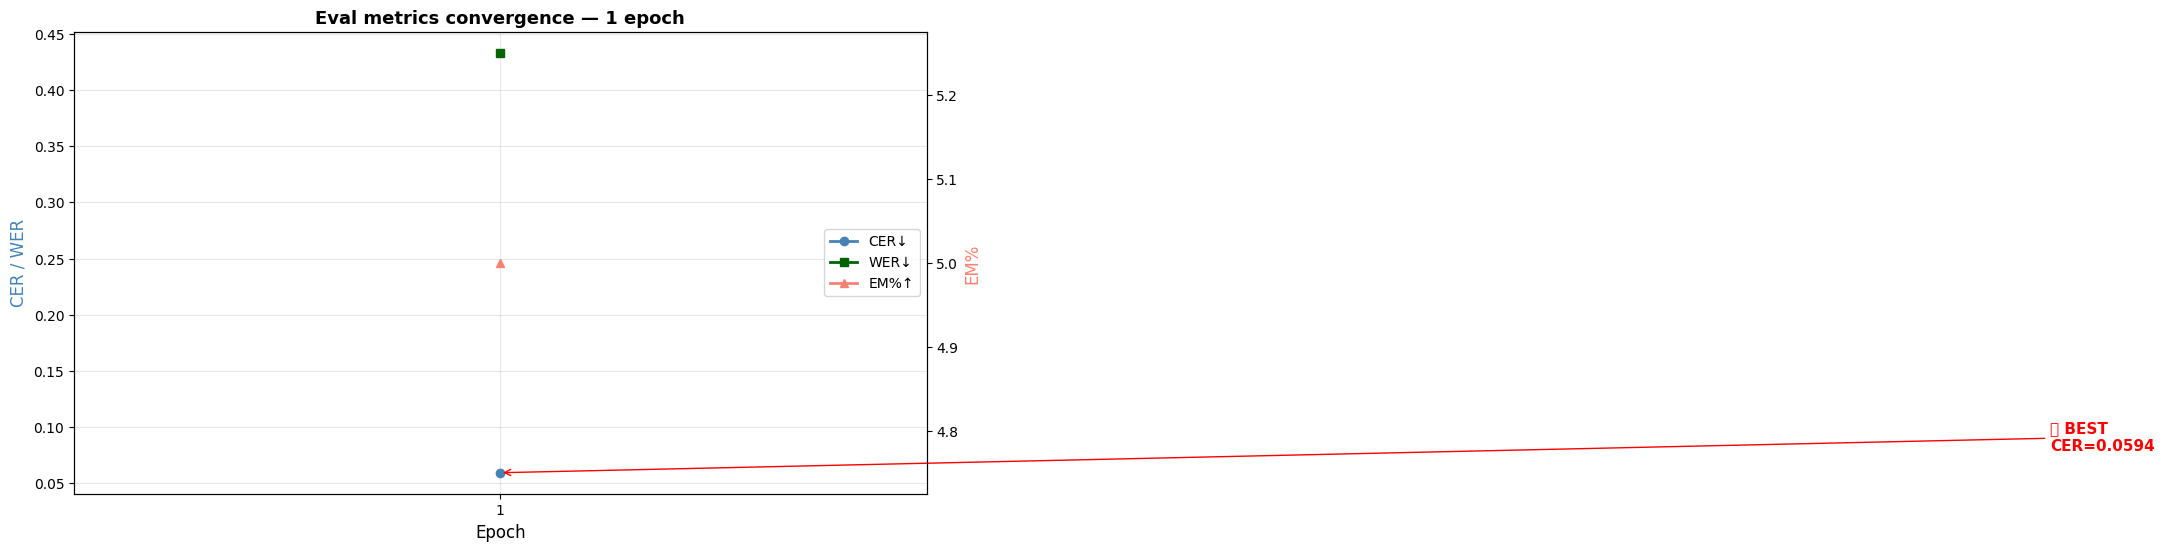


[Vẽ 3/6: Tone accuracy theo epoch]


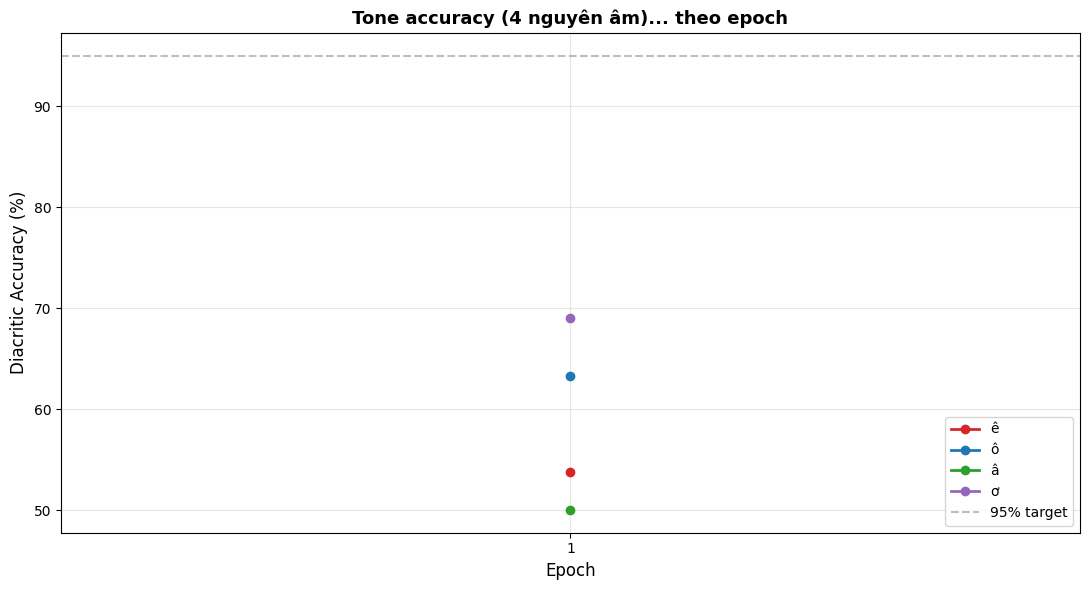


[Vẽ 4/6: Edit operations theo epoch]


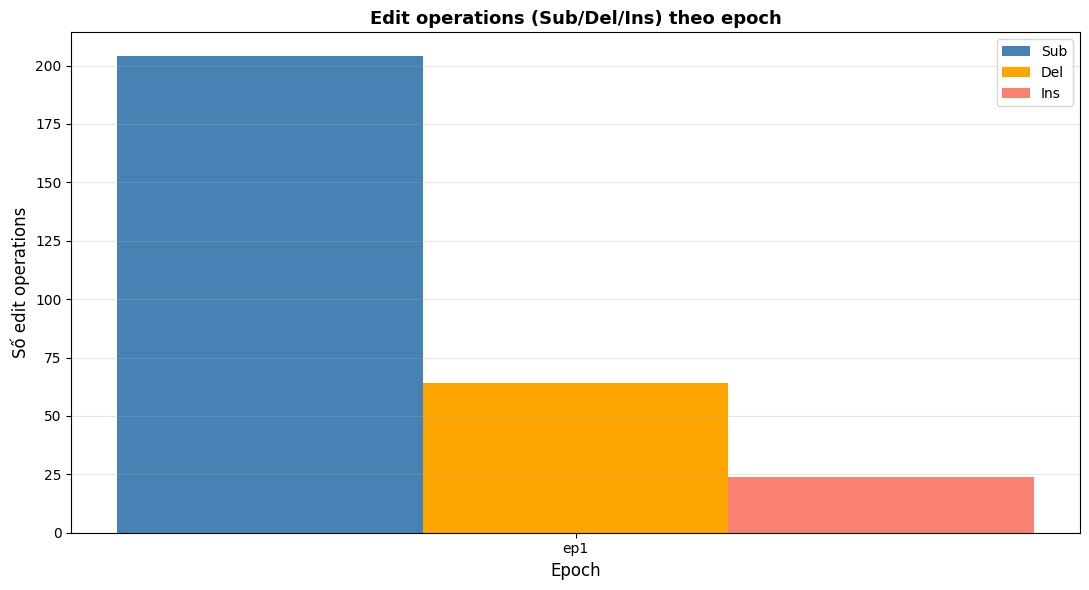


[Vẽ 5/6: Train loss (cuối ep) vs CER]

[Vẽ 6/6: Heatmap dashboard tổng hợp]


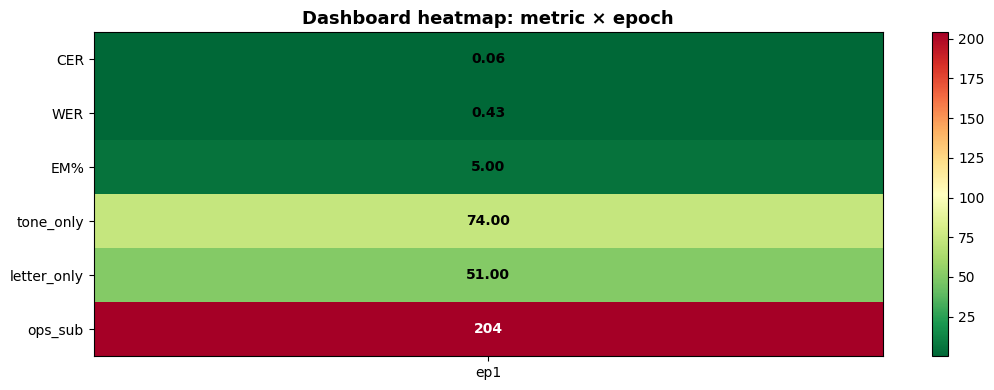


  🎯 SUMMARY: BASE → BEST (ep1)
  CER      : 0.0598 → 0.0594  (1.0× improvement)
  WER      : 0.4387 → 0.4332
  EM%      : 5.0 → 5.0
  Test samples: 20
  Train time: 46s = 0.8 phút

  📊 6 dashboard PNG saved tại /kaggle/working/ocr_data/dash_*.png
  📂 Training metadata: /kaggle/working/ocr_data/train_metadata.json
  📂 Eval results (lite): /kaggle/working/ocr_data/experiment_v2_results.json


In [10]:
# ═════════════════════════════════════════════════════════════════
# 📈 TRAINING DASHBOARD  (đọc train_metadata + eval results)
# ═════════════════════════════════════════════════════════════════
# Tổng hợp toàn cảnh training + eval:
#   1) Loss curve theo step (log_history từ trainer_state.json)
#   2) LR schedule theo step
#   3) Grad norm theo step (phát hiện instability)
#   4) CER/WER/EM% theo epoch (đường cong hội tụ)
#   5) Tone accuracy 4 nguyên âm (ê/ô/â/ơ) theo epoch
#   6) Comparison table (CER vs ops vs tone_acc) — lựa chọn best epoch
#
# Chỉ phụ thuộc 2 file JSON đã được persist (restart-safe):
#   • train_metadata.json     (log_history + hyperparams)
#   • experiment_v2_results.json  (per-epoch CER/WER/EM/tone_acc)
# ═════════════════════════════════════════════════════════════════
import os, json
import numpy as np
import matplotlib.pyplot as plt

# Paths set ở CONFIG cell: OUT_DIR, TRAIN_META, RESULTS_V2

assert os.path.exists(TRAIN_META), f"Thiếu {TRAIN_META}\n→ Chạy cell TRAIN (mục 6) trước."
assert os.path.exists(RESULTS_V2), f"Thiếu {RESULTS_V2}\n→ Chạy cell EVAL (mục 7) trước."

# ── Load dữ liệu ─────────────────────────────────────────────────
with open(TRAIN_META) as f: meta = json.load(f)
with open(RESULTS_V2) as f: results = json.load(f)

log_history = meta.get("log_history", [])
EPOCHS      = meta.get("EPOCHS")
train_total = meta.get("train_total_s", 0)
N_GPUS      = meta.get("N_GPUS")
EFF_BS      = meta.get("EFFECTIVE_BS")

print(f"📌 EPOCHS = {EPOCHS}  |  train_total = {train_total:.0f}s ({train_total/60:.1f} phút)")
print(f"📌 log_history: {len(log_history)} entries")

# Filter log_history: chỉ giữ entries có 'loss' hoặc chỉ 'eval_loss'
train_logs = [e for e in log_history if "loss" in e]
eval_logs  = [e for e in log_history if "eval_loss" in e]

if train_logs:
    print(f"📌 Train loss range: {min(e['loss'] for e in train_logs):.3f} → "
          f"{max(e['loss'] for e in train_logs):.3f}")
print()

# ─── Helper: align eval metrics với train step (cho dual-axis plot) ───
# results[0] = base (ep0, không train), results[1..N] = ep1..N
ft_results   = [r for r in results if r.get("epoch", 0) > 0]
epoch_idx    = [r["epoch"] for r in ft_results]
cer_per_ep   = [r["CER"]  for r in ft_results]
wer_per_ep   = [r["WER"]  for r in ft_results]
em_per_ep    = [r["EM%"]  for r in ft_results]
sub_per_ep   = [r["ops_sub"] for r in ft_results]
tone4 = ["ê", "ô", "â", "ơ"]
tone_acc_per_ep = {b: [r["tone_acc"].get(b, 0) for r in ft_results] for b in tone4}

# ═════════════════════════════════════════════════════════════════
# PLOT 1/6: Loss + LR + Grad norm  (3 subplots)
# ═════════════════════════════════════════════════════════════════
print("[Vẽ 1/6: Loss + LR + Grad norm]")
if train_logs:
    steps = [e["step"] for e in train_logs]
    losses = [e["loss"] for e in train_logs]
    lrs    = [e.get("learning_rate", 0) for e in train_logs]
    grads  = [e.get("grad_norm", None) for e in train_logs]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot(steps, losses, color='steelblue', alpha=0.8, linewidth=1.5)
    # EMA smoothed
    if len(losses) > 20:
        ema = [losses[0]]
        for x in losses[1:]:
            ema.append(0.9 * ema[-1] + 0.1 * x)
        axes[0].plot(steps, ema, color='red', linewidth=2, label='EMA(0.9)')
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Train Loss", fontsize=12)
    axes[0].set_title("Training Loss", fontweight='bold')
    axes[0].grid(alpha=0.3); axes[0].legend()

    # LR schedule
    axes[1].plot(steps, lrs, color='darkgreen', linewidth=1.5)
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Learning Rate", fontsize=12)
    axes[1].set_title("LR Schedule", fontweight='bold')
    axes[1].grid(alpha=0.3)

    # Grad norm
    if any(g is not None for g in grads):
        axes[2].plot(steps, [g if g is not None else 0 for g in grads],
                     color='darkred', linewidth=1.2)
        axes[2].set_xlabel("Step")
        axes[2].set_ylabel("Grad Norm", fontsize=12)
        axes[2].set_title("Gradient Norm (instability check)", fontweight='bold')
        axes[2].grid(alpha=0.3)
    else:
        axes[2].text(0.5, 0.5, "No grad_norm\ndata", ha='center', va='center', fontsize=14)
        axes[2].set_axis_off()

    # Đánh dấu ranh giới epoch (dọc)
    if EPOCHS:
        last_step = steps[-1]
        for ep in range(1, EPOCHS):
            boundary = int(last_step * ep / EPOCHS)
            for ax in axes[:2]:
                ax.axvline(boundary, color='gray', linestyle=':', alpha=0.5)

    plt.suptitle(f"Training dynamics — {EPOCHS} epoch, {len(steps)} steps logged",
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/dash_training_dynamics.png", dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("  (Không có train_logs — bỏ qua)")

# ═════════════════════════════════════════════════════════════════
# PLOT 2/6: CER + WER + EM% theo epoch (convergence curve)
# ═════════════════════════════════════════════════════════════════
print("\n[Vẽ 2/6: CER/WER/EM% theo epoch]")
if ft_results:
    fig, ax1 = plt.subplots(figsize=(11, 6))
    ax2 = ax1.twinx()

    l1, = ax1.plot(epoch_idx, cer_per_ep, 'o-', color='steelblue', linewidth=2, label='CER↓')
    l2, = ax1.plot(epoch_idx, wer_per_ep, 's-', color='darkgreen', linewidth=2, label='WER↓')
    l3, = ax2.plot(epoch_idx, em_per_ep,  '^-', color='salmon', linewidth=2, label='EM%↑')

    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("CER / WER", fontsize=12, color='steelblue')
    ax2.set_ylabel("EM%", fontsize=12, color='salmon')
    ax1.set_title(f"Eval metrics convergence — {len(ft_results)} epoch",
                  fontsize=13, fontweight='bold')
    ax1.set_xticks(epoch_idx)
    ax1.grid(alpha=0.3)
    ax1.legend(handles=[l1, l2, l3], loc='center right')

    # Đánh dấu best
    best_i = int(np.argmin(cer_per_ep))
    ax1.annotate(f"🏆 BEST\nCER={cer_per_ep[best_i]:.4f}",
                 xy=(epoch_idx[best_i], cer_per_ep[best_i]),
                 xytext=(epoch_idx[best_i]+0.2, cer_per_ep[best_i]+0.02),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=11, color='red', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/dash_metrics_convergence.png", dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("  (Không có ft_results — bỏ qua)")

# ═════════════════════════════════════════════════════════════════
# PLOT 3/6: Tone accuracy 4 nguyên âm theo epoch
# ═════════════════════════════════════════════════════════════════
print("\n[Vẽ 3/6: Tone accuracy theo epoch]")
if ft_results and tone4:
    fig, ax = plt.subplots(figsize=(11, 6))
    colors = {'ê': 'tab:red', 'ô': 'tab:blue', 'â': 'tab:green', 'ơ': 'tab:purple'}
    for b in tone4:
        vals = tone_acc_per_ep[b]
        ax.plot(epoch_idx, vals, 'o-', color=colors[b], linewidth=2, label=f'{b}')
    ax.axhline(95, color='gray', linestyle='--', alpha=0.5, label='95% target')
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Diacritic Accuracy (%)", fontsize=12)
    ax.set_title("Tone accuracy (4 nguyên âm)... theo epoch",
                 fontsize=13, fontweight='bold')
    ax.set_xticks(epoch_idx)
    ax.grid(alpha=0.3); ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/dash_tone_acc_per_epoch.png", dpi=100, bbox_inches='tight')
    plt.show()

# ═════════════════════════════════════════════════════════════════
# PLOT 4/6: Substitution + Del + Ins (edit ops) — grouped bar
# ═════════════════════════════════════════════════════════════════
print("\n[Vẽ 4/6: Edit operations theo epoch]")
if ft_results:
    fig, ax = plt.subplots(figsize=(11, 6))
    x = np.arange(len(epoch_idx))
    w = 0.25
    subs = [r["ops_sub"] for r in ft_results]
    dels = [r["ops_del"] for r in ft_results]
    inss = [r["ops_ins"] for r in ft_results]
    ax.bar(x - w, subs, w, label='Sub', color='steelblue')
    ax.bar(x,     dels, w, label='Del', color='orange')
    ax.bar(x + w, inss, w, label='Ins', color='salmon')
    ax.set_xticks(x); ax.set_xticklabels([f"ep{e}" for e in epoch_idx])
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Số edit operations", fontsize=12)
    ax.set_title("Edit operations (Sub/Del/Ins) theo epoch",
                 fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3, axis='y'); ax.legend()
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/dash_edit_ops.png", dpi=100, bbox_inches='tight')
    plt.show()

# ═════════════════════════════════════════════════════════════════
# PLOT 5/6: Loss chi tiết theo epoch (gộp train loss cuối + eval metrics)
# ═════════════════════════════════════════════════════════════════
print("\n[Vẽ 5/6: Train loss (cuối ep) vs CER]")
if train_logs and ft_results:
    # Tìm loss trung bình mỗi epoch (chia log_history làm EPOCHS phần)
    steps_per_epoch = max(e["step"] for e in train_logs) // EPOCHS if EPOCHS else 1
    train_loss_per_ep = []
    for ep in range(EPOCHS):
        ep_logs = [e["loss"] for e in train_logs
                   if ep * steps_per_epoch < e["step"] <= (ep+1) * steps_per_epoch]
        if ep_logs:
            train_loss_per_ep.append(sum(ep_logs) / len(ep_logs))
        else:
            train_loss_per_ep.append(None)
    valid_eps = [i+1 for i, v in enumerate(train_loss_per_ep) if v is not None]
    valid_train_loss = [v for v in train_loss_per_ep if v is not None]

    if valid_eps:
        fig, ax1 = plt.subplots(figsize=(11, 6))
        ax2 = ax1.twinx()
        l1, = ax1.plot(valid_eps, valid_train_loss, 'o-', color='purple',
                       linewidth=2, label='Train Loss (avg/epoch)')
        # Match với CER cùng epoch (lấy step tương ứng)
        cer_match = [cer_per_ep[i-1] for i in valid_eps if i-1 < len(cer_per_ep)]
        cer_ep    = [i for i in valid_eps if i-1 < len(cer_per_ep)]
        l2, = ax2.plot(cer_ep, cer_match, 's-', color='steelblue',
                       linewidth=2, label='CER')
        ax1.set_xlabel("Epoch", fontsize=12)
        ax1.set_ylabel("Train Loss", color='purple', fontsize=12)
        ax2.set_ylabel("CER", color='steelblue', fontsize=12)
        ax1.set_title("Train loss (avg/epoch) vs CER — hội tụ?",
                      fontsize=13, fontweight='bold')
        ax1.set_xticks(valid_eps)
        ax1.grid(alpha=0.3)
        ax1.legend(handles=[l1, l2], loc='upper right')
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/dash_loss_vs_cer.png", dpi=100, bbox_inches='tight')
        plt.show()

# ═════════════════════════════════════════════════════════════════
# PLOT 6/6: Bảng dashboard dạng heatmap (epoch × metric)
# ═════════════════════════════════════════════════════════════════
print("\n[Vẽ 6/6: Heatmap dashboard tổng hợp]")
if ft_results:
    metrics = ["CER", "WER", "EM%", "tone_only", "letter_only", "ops_sub"]
    rows = []
    for r in ft_results:
        rows.append([r["CER"], r["WER"], r["EM%"],
                     r["tone_only"], r["letter_only"], r["ops_sub"]])
    data = np.array(rows).T  # metric × epoch

    fig, ax = plt.subplots(figsize=(11, 4))
    im = ax.imshow(data, cmap='RdYlGn_r', aspect='auto')

    ax.set_xticks(range(len(epoch_idx))); ax.set_xticklabels([f"ep{e}" for e in epoch_idx])
    ax.set_yticks(range(len(metrics)));   ax.set_yticklabels(metrics)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            color = 'white' if v > np.nanmax(data)*0.6 else 'black'
            ax.text(j, i, f"{v:.2f}" if v < 100 else f"{int(v)}",
                    ha='center', va='center', color=color, fontsize=10, fontweight='bold')
    ax.set_title("Dashboard heatmap: metric × epoch",
                 fontsize=13, fontweight='bold')
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/dash_heatmap_summary.png", dpi=100, bbox_inches='tight')
    plt.show()

# ═════════════════════════════════════════════════════════════════
# CONSOLE: so sánh best vs base (verbal summary)
# ═════════════════════════════════════════════════════════════════
if results and ft_results:
    r0  = results[0]
    rB  = min(ft_results, key=lambda x: x["CER"])
    print(f"\n{'='*70}")
    print(f"  🎯 SUMMARY: BASE → BEST (ep{rB['epoch']})")
    print(f"{'='*70}")
    print(f"  CER      : {r0['CER']:.4f} → {rB['CER']:.4f}  "
          f"({r0['CER']/max(rB['CER'],1e-9):.1f}× improvement)")
    print(f"  WER      : {r0['WER']:.4f} → {rB['WER']:.4f}")
    print(f"  EM%      : {r0['EM%']:.1f} → {rB['EM%']:.1f}")
    print(f"  Test samples: {rB.get('n','—')}")
    print(f"  Train time: {train_total:.0f}s = {train_total/60:.1f} phút")
    if train_logs:
        print(f"  Train loss: {train_logs[0]['loss']:.3f} (đầu) → "
              f"{train_logs[-1]['loss']:.3f} (cuối)")
    print(f"\n  📊 6 dashboard PNG saved tại {OUT_DIR}/dash_*.png")
    print(f"  📂 Training metadata: {TRAIN_META}")
    print(f"  📂 Eval results (lite): {RESULTS_V2}")


**📖 Hướng dẫn đọc bảng kết quả:**

| Cột | Ý nghĩa | Tốt khi |
|-----|---------|----------|
| **CER** | Character Error Rate — tỷ lệ ký tự sai | **Thấp** (0.0 = hoàn hảo) |
| **WER** | Word Error Rate — tỷ lệ từ sai | **Thấp** (0.0 = hoàn hảo) |
| **EM%** | Exact Match — % sample đoán đúng 100% | **Cao** |
| **DA%** | Diacritic Accuracy — % dấu TV đoán đúng | **Cao** (≥95% = tốt) |
| **ă â ê ô ơ ư đ** | Accuracy riêng từng nhóm nguyên âm kép | **Cao** (nhóm nào thấp cần thêm data) |

- [+] = cải thiện so epoch trước | [-] = giảm | [=] = không đổi
- Nếu DA% ≥ 95% -> model đã sẵn sàng trong `/kaggle/working/ocr_data/glm-ocr-vn-v2-ep5/`
- Nếu DA% < 95% hoặc có nhóm < 80% -> chạy lại cell experiment ở **mục 6** (tăng `EPOCHS`) -> chạy lại eval
- Nếu epoch mới toàn [-] -> **overfitting**, dùng checkpoint epoch trước

In [11]:
# ## 7. Test ảnh bất kỳ

# Upload 1 ảnh từ máy -> chạy OCR bằng model đã finetune.
# Dùng để test nhanh kết quả thực tế sau mỗi epoch.



# @title Test ảnh (Upload HOẶC tự pick từ dataset)
import io, os, glob, json as _json
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText

# Paths set ở CONFIG cell (cell 1): RESULTS_V2, MODEL_DIR, OUT_DIR.
# Auto-detect BEST epoch:
_best_ep = 4
if os.path.exists(RESULTS_V2):
    with open(RESULTS_V2) as _f:
        _res = _json.load(_f)
    _ft = [r for r in _res if r.get("epoch", 0) > 0]
    if _ft:
        _best_ep = min(_ft, key=lambda x: x["CER"])["epoch"]

ORIG_DIR = os.environ.get("ORIG_DIR", MODEL_DIR)
FT_DIR   = os.environ.get("FT_DIR", os.path.join(OUT_DIR, f"glm-ocr-vn-v2-ep{_best_ep}"))
print(f"📌 Test bằng BEST epoch = {_best_ep}  →  {FT_DIR}")

# ═══════════════════════════════════════════════════════════════════
# CONFIG: chọn cách lấy ảnh
# ═══════════════════════════════════════════════════════════════════
# MODE = "upload"  → Hiện nút chọn file từ máy tính và nút bấm chạy OCR
# MODE = "dataset" → Tự pick N ảnh ngẫu nhiên từ /kaggle/input
# MODE = "path"    → Dùng 1 ảnh cụ thể ở TEST_IMAGE_PATH
MODE = "upload" 

N_DATASET_SAMPLES = 5            
TEST_IMAGE_PATH = ""             
KAGGLE_IMAGES = "/kaggle/input/datasets/dngnguyntun2/vietnamese-ocr/vietnamese_ocr/images"
# ═══════════════════════════════════════════════════════════════════

# ── 1. LOAD MODELS TRƯỚC (Chỉ load 1 lần để tiết kiệm RAM/Thời gian) ──
print('⏳ Loading original (base) model...')
orig_proc = AutoProcessor.from_pretrained(ORIG_DIR, trust_remote_code=True)
orig_mdl = AutoModelForImageTextToText.from_pretrained(
    ORIG_DIR, trust_remote_code=True, torch_dtype='auto', device_map='auto'
)

print(f'⏳ Loading finetuned model: {FT_DIR}...')
processor = AutoProcessor.from_pretrained(FT_DIR, trust_remote_code=True)
model = AutoModelForImageTextToText.from_pretrained(
    FT_DIR, trust_remote_code=True, torch_dtype='auto', device_map='auto'
)
print('✓ Load models hoàn tất!')

# ── 2. HÀM XỬ LÝ OCR & IN KẾT QUẢ ──
def run_ocr(proc, mdl, image_path):
    messages = [{'role': 'user', 'content': [
        {'type': 'image', 'url': image_path},
        {'type': 'text', 'text': 'Table Recognition:'},
    ]}]
    inputs = proc.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors='pt'
    ).to(mdl.device)
    inputs.pop('token_type_ids', None)
    ids = mdl.generate(**inputs, max_new_tokens=512, do_sample=False)
    return proc.decode(ids[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()

def process_and_display_ocr(paths):
    """Hàm trung gian để loop qua các ảnh và in kết quả so sánh"""
    if not paths:
        print("❌ Không có ảnh nào để test.")
        return
        
    for idx, img_path in enumerate(paths, 1):
        img = Image.open(img_path).convert('RGB')
        print(f"\n{'='*60}\n ẢNH {idx}/{len(paths)}: {os.path.basename(img_path)} ({img.size[0]}x{img.size[1]})\n{'='*60}")

        result_orig = run_ocr(orig_proc, orig_mdl, img_path)
        result_ft = run_ocr(processor, model, img_path)

        print(f'\n{"─"*25} ORIGINAL (base) {"─"*25}')
        print(result_orig)
        print(f'\n{"─"*20} FINETUNED ({os.path.basename(FT_DIR)}) {"─"*20}')
        print(result_ft)

        if result_orig != result_ft:
            print(f'\n{"─"*30} DIFF {"─"*30}')
            ow, fw = result_orig.split(), result_ft.split()
            for i in range(max(len(ow), len(fw))):
                o = ow[i] if i < len(ow) else "<missing>"
                f = fw[i] if i < len(fw) else "<missing>"
                if o != f:
                    print(f'  [{i}] "{o}" -> "{f}"')
        else:
            print('\n  ✓ Cả hai giống hệt nhau.')
            
        from IPython.display import display as _disp
        _disp(img)

# ── 3. ĐIỀU HƯỚNG LOGIC THEO MODE ──
if MODE == "upload":
    import ipywidgets as widgets
    from IPython.display import display

    # Tạo widget upload và nút bấm kích hoạt
    uploader = widgets.FileUpload(accept='image/*', multiple=True, description="1. Chọn ảnh từ máy")
    btn_run = widgets.Button(description="2. 🚀 Chạy OCR ảnh đã chọn", button_style='success')
    output_area = widgets.Output() # Đảm bảo dữ liệu hiển thị đúng vị trí dưới nút bấm

    # Hiển thị giao diện điều khiển lên màn hình
    display(widgets.VBox([uploader, btn_run, output_area]))

    # Định nghĩa hành động khi bấm nút "Chạy OCR"
    def on_button_clicked(b):
        with output_area:
            output_area.clear_output() # Xóa kết quả của lần bấm trước đó
            if not uploader.value:
                print("❌ Bạn chưa chọn file ảnh nào cả! Hãy click nút '1. Chọn ảnh từ máy' trước.")
                return
            
            print("⏳ Đang giải mã và lưu tạm file...")
            image_paths = []
            
            # Tương thích cho cả ipywidgets phiên bản cũ (dict) và mới (tuple/list)
            file_items = uploader.value if isinstance(uploader.value, tuple) else uploader.value.values()
            
            for finfo in file_items:
                tmp_path = f"/tmp/{finfo['name']}"
                content = finfo['content']
                with open(tmp_path, "wb") as f:
                    f.write(content.tobytes() if hasattr(content, 'tobytes') else content)
                image_paths.append(tmp_path)
                print(f"✓ Đã nạp file: {finfo['name']}")
            
            print(f"🔥 Bắt đầu chạy OCR cho {len(image_paths)} file...")
            process_and_display_ocr(image_paths)

    btn_run.on_click(on_button_clicked)

elif MODE == "path":
    assert TEST_IMAGE_PATH and os.path.exists(TEST_IMAGE_PATH), f"TEST_IMAGE_PATH không tồn tại: {TEST_IMAGE_PATH}"
    print(f"Test 1 ảnh cụ thể: {TEST_IMAGE_PATH}")
    process_and_display_ocr([TEST_IMAGE_PATH])

elif MODE == "dataset":
    assert os.path.exists(KAGGLE_IMAGES), f"Không tìm thấy ảnh dataset ở {KAGGLE_IMAGES}"
    all_imgs = sorted(glob.glob(os.path.join(KAGGLE_IMAGES, "*.png")))
    assert len(all_imgs) >= N_DATASET_SAMPLES, "Không đủ ảnh trong dataset"
    import random as _r
    sampled_paths = _r.Random(0).sample(all_imgs, min(N_DATASET_SAMPLES, len(all_imgs)))
    print(f"Test {len(sampled_paths)} ảnh ngẫu nhiên từ dataset")
    process_and_display_ocr(sampled_paths)

📌 Test bằng BEST epoch = 1  →  /kaggle/working/ocr_data/glm-ocr-vn-v2-ep1
⏳ Loading original (base) model...


Loading weights:   0%|          | 0/510 [00:00<?, ?it/s]

⏳ Loading finetuned model: /kaggle/working/ocr_data/glm-ocr-vn-v2-ep1...


Loading weights:   0%|          | 0/510 [00:00<?, ?it/s]

✓ Load models hoàn tất!


In [12]:
# ═════════════════════════════════════════════════════════════════
# 📦 PUBLISH-PREP: copy BEST model ra top-level + sinh model card
# ═════════════════════════════════════════════════════════════════
# Tại sao cần cell này:
#   Kaggle Models UI khi upload từ notebook output CHỈ browse được
#   top-level của /kaggle/working/, KHÔNG vào sâu subfolder được.
#   → phải copy folder model BEST ra top-level để UI nhìn thấy.
#
# Output:
#   /kaggle/working/glm-ocr-vn-best/    ← standalone model ready to upload
#       ├── (tất cả file model gốc)
#       ├── README.md                   ← model card tự sinh
#       └── results_summary.json        ← metrics ep0 vs ep{BEST}
# ═════════════════════════════════════════════════════════════════
import os, json, shutil

# Paths set ở CONFIG cell (cell 1): OUT_DIR, RESULTS_V2, BEST_DEST
DEST = BEST_DEST   # alias cho dễ đọc bên dưới

# ── Auto-detect BEST epoch từ results JSON, fallback ep4 ─────────
best_ep = 4
results = []
if os.path.exists(RESULTS_V2):
    with open(RESULTS_V2) as f:
        results = json.load(f)
    ft = [r for r in results if r.get("epoch", 0) > 0]
    if ft:
        best_dict = min(ft, key=lambda x: x["CER"])
        best_ep = best_dict["epoch"]

SRC = os.path.join(OUT_DIR, f"glm-ocr-vn-v2-ep{best_ep}")
assert os.path.exists(SRC), (
    f"Model BEST không tồn tại: {SRC}\n"
    f"→ Phải chạy cell EVAL (cell 15) để merge ep{best_ep} trước."
)

# ── Copy folder BEST ra top-level ────────────────────────────────
if os.path.exists(DEST):
    shutil.rmtree(DEST)
shutil.copytree(SRC, DEST)

# Tính size
total_bytes = sum(os.path.getsize(os.path.join(r, f))
                  for r, _, fs in os.walk(DEST) for f in fs)
print(f"✓ Copied ep{best_ep} → {DEST}")
print(f"  Size: {total_bytes/1e9:.2f} GB ({total_bytes:,} bytes)")
print(f"  Files: {len(os.listdir(DEST))}")
for fn in sorted(os.listdir(DEST)):
    sz = os.path.getsize(os.path.join(DEST, fn))
    print(f"    {fn:<40} {sz/1e6:>8.1f} MB")

# ── Sinh model card README.md ────────────────────────────────────
def _find(r, key, default="—"):
    for x in r:
        if x.get("epoch") == key:
            return x
    return {}

r0  = _find(results, 0)
rB  = _find(results, best_ep)
ta0 = r0.get("tone_acc", {})
taB = rB.get("tone_acc", {})

card = f"""# GLM-OCR Vietnamese (fine-tuned for diacritical marks)

## 📌 Model card

| Trường | Giá trị |
|---|---|
| **Base model** | [`zai-org/GLM-OCR`](https://huggingface.co/zai-org/GLM-OCR) |
| **Method** | LoRA fine-tune (rank=16, alpha=64, dropout=0.1) |
| **Resolution bottleneck** | `freeze_vision_tower: false` → vision tower học lại đặc trưng dấu thanh |
| **LoRA targets** | `q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj` (LM-only) |
| **Training data** | 30,000 Vietnamese OCR samples (text line images) |
| **Epochs** | {best_ep} (best out of 5) |
| **Hardware** | Kaggle T4 × 2, fp16, gradient_checkpointing=true |
| **Optimizer** | AdamW, lr=1e-4, constant_with_warmup, warmup_ratio=0.05 |
| **Effective batch size** | 32 (8 × 2 GPU × 2 grad_accum) |

## 📊 Results ({rB.get('n', '—')} test samples)

| Epoch | CER ↓ | WER ↓ | EM% ↑ | ê | ô | â | ơ |
|---|---|---|---|---|---|---|---|
| 0 (base) | {r0.get('CER','—')} | {r0.get('WER','—')} | {r0.get('EM%','—')} | {ta0.get('ê','—')} | {ta0.get('ô','—')} | {ta0.get('â','—')} | {ta0.get('ơ','—')} |
| **{best_ep} (best)** | **{rB.get('CER','—')}** | **{rB.get('WER','—')}** | **{rB.get('EM%','—')}** | **{taB.get('ê','—')}** | **{taB.get('ô','—')}** | **{taB.get('â','—')}** | **{taB.get('ơ','—')}** |

Improvement: CER {r0.get('CER','—')} → {rB.get('CER','—')}
{(r0.get('CER',1)/rB.get('CER',1) if rB.get('CER') else '—'):.1f}× reduction.

## 🧪 Cách dùng

```python
from transformers import AutoProcessor, AutoModelForImageTextToText

proc = AutoProcessor.from_pretrained("YOUR_KAGGLE_MODEL_HANDLE", trust_remote_code=True)
mdl  = AutoModelForImageTextToText.from_pretrained(
    "YOUR_KAGGLE_MODEL_HANDLE", trust_remote_code=True, torch_dtype="auto"
)

messages = [{{"role": "user", "content": [
    {{"type": "image", "url": "path/to/image.png"}},
    {{"type": "text", "text": "Text Recognition:"}},
]}}]
inputs = proc.apply_chat_template(messages, tokenize=True,
    add_generation_prompt=True, return_dict=True, return_tensors="pt")
inputs = inputs.to(mdl.device)
inputs.pop("token_type_ids", None)

gen = mdl.generate(**inputs, max_new_tokens=512, do_sample=False)
text = proc.decode(gen[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
print(text)
```

## 📚 Attribution

- Fine-tuned from [`zai-org/GLM-OCR`](https://huggingface.co/zai-org/GLM-OCR).
- Training data: [`dngnguyntun2/vietnamese-ocr`](https://www.kaggle.com/datasets/dngnguyntun2/vietnamese-ocr).
- Training notebook: [`dngnguyntun2/glm-ocr-vn`](https://www.kaggle.com/code/dngnguyntun2/glm-ocr-vn).

## ⚠️ License

Phụ thuộc license của base model `zai-org/GLM-OCR`. Kiểm tra tại:
https://huggingface.co/zai-org/GLM-OCR/blob/main/LICENSE
trước khi redistribute.
"""

card_path = os.path.join(DEST, "README.md")
with open(card_path, "w", encoding="utf-8") as f:
    f.write(card)
print(f"\n✓ Wrote model card: {card_path}")

# ── Lưu summary metrics ──────────────────────────────────────────
summary_path = os.path.join(DEST, "results_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump({
        "best_epoch": best_ep,
        "base_metrics":   _find(results, 0),
        "best_metrics":   _find(results, best_ep),
        "all_epochs":     results,
    }, f, indent=2, ensure_ascii=False)
print(f"✓ Wrote results summary: {summary_path}")

# ── Hướng dẫn publish lên Kaggle Models ──────────────────────────
print(f"\n{'='*70}")
print(f"  🚀 HƯỚNG DẪN UPLOAD LÊN KAGGLE MODELS (UI)")
print(f"{'='*70}")
print(f"""
  1. Save Version notebook này (File → Save Version → Commit)
     → output `{DEST}` sẽ được persist.

  2. Mở: https://www.kaggle.com/models → New Model

  3. Điền:
     - Name: glm-ocr-vn
     - Framework: PyTorch  (hoặc Transformers)
     - License: (chọn theo base — check HF của zai-org/GLM-OCR)

  4. Upload folder → Browse → chọn: glm-ocr-vn-best/
     (folder ở top-level, UI sẽ thấy được)

  5. Drag README.md content vào ô Description, hoặc để file README.md
     trong folder khi upload.

  6. Visibility: Public nếu license base cho phép, Private nếu chỉ mình xài.

  ⏱️  Verify sau khi upload (~5 phút):
     ```python
     from transformers import AutoModelForImageTextToText
     m = AutoModelForImageTextToText.from_pretrained(
         "<your-kaggle-handle>/glm-ocr-vn/pyTorch/1",
         trust_remote_code=True
     )
     ```
""")


✓ Copied ep1 → /kaggle/working/glm-ocr-vn-best
  Size: 2.22 GB (2,221,719,826 bytes)
  Files: 8
    Modelfile                                     0.0 MB
    chat_template.jinja                           0.0 MB
    config.json                                   0.0 MB
    generation_config.json                        0.0 MB
    model.safetensors                          2214.9 MB
    processor_config.json                         0.0 MB
    tokenizer.json                                6.8 MB
    tokenizer_config.json                         0.0 MB

✓ Wrote model card: /kaggle/working/glm-ocr-vn-best/README.md
✓ Wrote results summary: /kaggle/working/glm-ocr-vn-best/results_summary.json

  🚀 HƯỚNG DẪN UPLOAD LÊN KAGGLE MODELS (UI)

  1. Save Version notebook này (File → Save Version → Commit)
     → output `/kaggle/working/glm-ocr-vn-best` sẽ được persist.

  2. Mở: https://www.kaggle.com/models → New Model

  3. Điền:
     - Name: glm-ocr-vn
     - Framework: PyTorch  (hoặc Transformers)